# BƯỚC 4.5: EDA & PHÂN TÍCH TƯƠNG QUAN
## Dự đoán Giá Dầu — Phân tích mối quan hệ (Chỉ Tập Train)

**Mục tiêu:** Phân tích dữ liệu đã xử lý để tìm ra mối liên hệ giữa các tính năng và biến mục tiêu, phát hiện đa cộng tuyến, kiểm tra tính dừng của chuỗi thời gian.

**Quan trọng:** Tất cả phân tích chỉ dùng tập **TRAIN (trước 2023-01-01)** để tránh rò rỉ dữ liệu.

**Tài liệu tham khảo:** CS313 - Tiền xử lý Dữ liệu (Vo Nguyen Le Duy)

---

### Nội dung:
1. Tải & Kiểm tra Dữ liệu Train
2. Phân tích Biến Mục tiêu (oil_return)
3. Kiểm tra Tính Dừng (Test ADF)
4. Phân tích Tự tương quan (ACF/PACF)
5. Tương quan Spearman theo Nhóm Tính năng
6. Tương quan Điểm song sát (Tính năng Nhị phân)
7. Bản đồ Tương quan & Đa cộng tuyến
8. Tương quan Rolling 90 ngày
9. Phát hiện & Phân tích Ngoại lệ
10. Bảng Thống kê Tóm tắt

In [2]:
# ============================================================================
# PHẦN 1: TẢI & KIỂM TRA DỮ LIỆU TRAIN
# ============================================================================

import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pointbiserialr, skew, kurtosis
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Tải dataset đã xử lý
df = pd.read_csv("../data/processed/dataset_step4_transformed.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Lọc chỉ tập huấn luyện (trước 2023-01-01)
# Lý do: Tránh rò rỉ dữ liệu - chỉ dùng thông tin quá khứ để quyết định loại tính năng
TRAIN_CUTOFF = pd.Timestamp("2023-01-01")
df_train = df[df["date"] < TRAIN_CUTOFF].copy()

print("="*80)
print("PHẦN 1: TẢI & KIỂM TRA DỮ LIỆU TRAIN")
print("="*80)
print(f"\nHình dạng dataset đầy đủ: {df.shape}")
print(f"Hình dạng tập train: {df_train.shape}")
print(f"Khoảng thời gian train: {df_train['date'].min().date()} → {df_train['date'].max().date()}")
print(f"\nKiểu dữ liệu:\n{df_train.dtypes}")
print(f"\nGiá trị thiếu trong tập train:\n{df_train.isnull().sum()[df_train.isnull().sum() > 0]}")
print(f"\n5 hàng đầu tiên:")
print(df_train.head())

PHẦN 1: TẢI & KIỂM TRA DỮ LIỆU TRAIN

Hình dạng dataset đầy đủ: (2923, 54)
Hình dạng tập train: (2083, 54)
Khoảng thời gian train: 2015-01-07 → 2022-12-30

Kiểu dữ liệu:
date                         datetime64[ns]
oil_close                           float64
usd_close                           float64
sp500_close                         float64
vix_close                           float64
yield_spread                        float64
wti_fred                            float64
fed_funds_rate_lag                  float64
cpi_lag                             float64
unemployment_lag                    float64
crude_inventory_weekly              float64
crude_production_weekly             float64
net_imports_weekly                  float64
inventory_change_pct                float64
gdelt_tone                          float64
gdelt_goldstein                     float64
gdelt_volume                        float64
gdelt_events                        float64
gdelt_tone_7d                       fl

In [3]:
# !pip install statsmodels

## PHẦN 2: PHÂN TÍCH BIẾN MỤC TIÊU (oil_return)

**Công thức:**
- **Skewness (γ₁):** Đo độ lệch của phân phối so với chuẩn. γ₁ > 0 = lệch phải, γ₁ < 0 = lệch trái
- **Kurtosis (γ₂):** Đo chiều dày của đuôi phân phối. γ₂ > 3 = tập trung ở đuôi (đặc trưng dữ liệu tài chính)
- **Boxplot:** Hiển thị Q1, trung vị, Q3, ngoại lệ theo nhóm

**Kỳ vọng:** `oil_return` sẽ có độ lệch âm (left skew), kurtosis cao (tập trung ở đuôi)


PHẦN 2: PHÂN TÍCH BIẾN MỤC TIÊU (oil_return)

Thống kê Cơ bản:
  Số lượng  : 2083
  Trung bình: 0.000599
  Trung vị  : 0.000633
  Độ lệch chuẩn: 0.026278
  Min      : -0.244036
  Max      : 0.210186
  Q1 (25%): -0.010648
  Q3 (75%): 0.012567

Hình dạng Phân phối:
  Skewness  : -0.388 (âm = đuôi trái)
  Kurtosis  : 12.064 (excess; >3 chỉ tập trung ở đuôi)
  Giải thích: TẬP TRUNG Ở ĐUÔI & LEPTOKURTIC


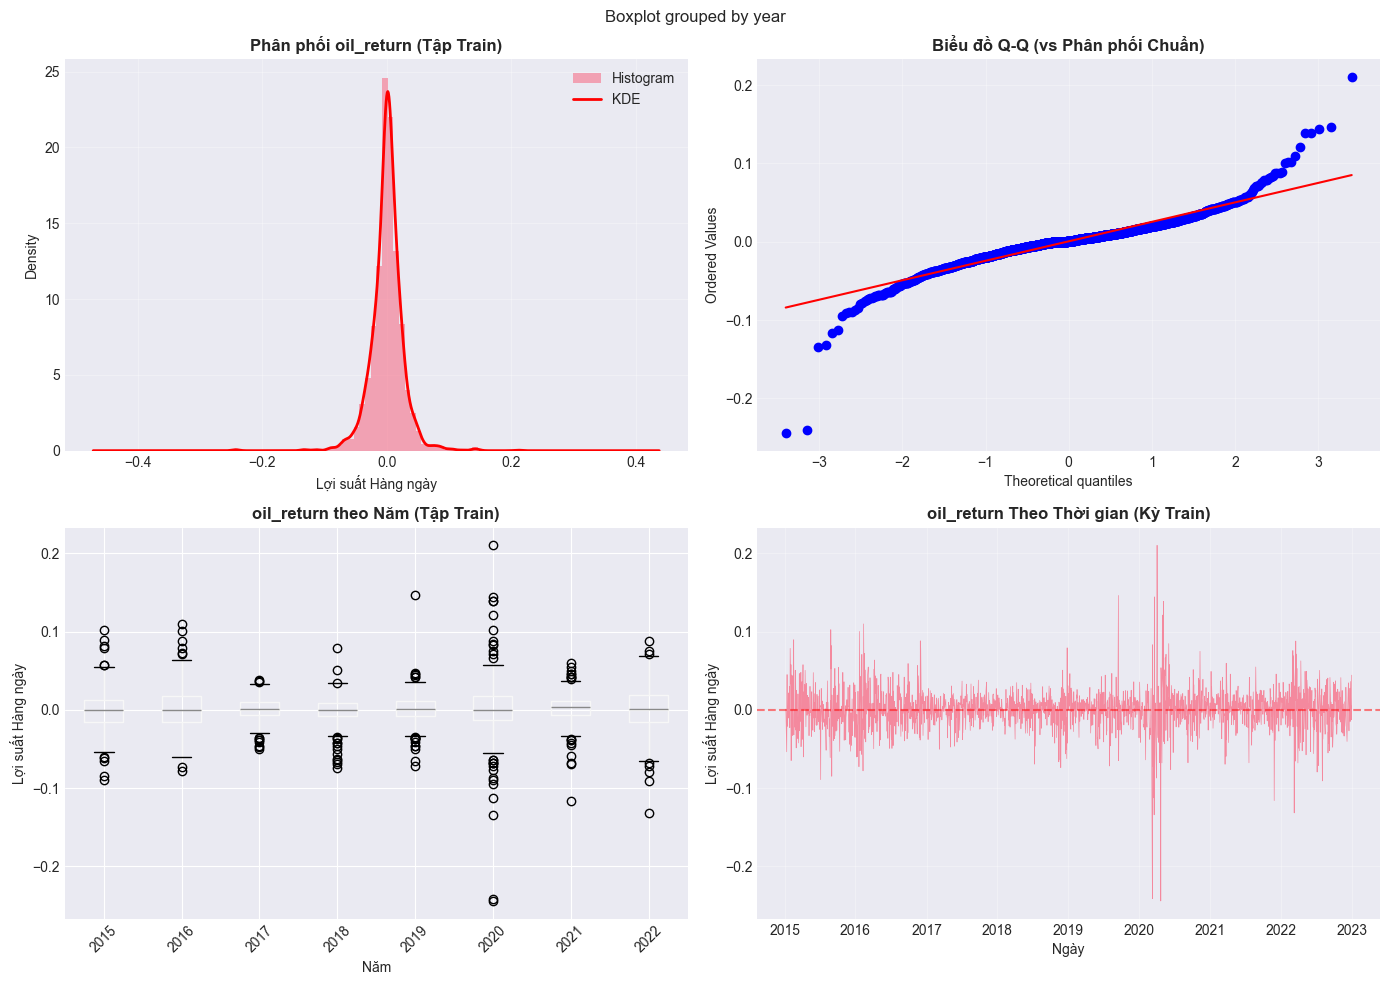


✓ Hình ảnh hoá hoàn tất


In [4]:
# Tính toán thống kê biến mục tiêu
oil_return = df_train["oil_return"].dropna()

print("\n" + "="*80)
print("PHẦN 2: PHÂN TÍCH BIẾN MỤC TIÊU (oil_return)")
print("="*80)

print(f"\nThống kê Cơ bản:")
print(f"  Số lượng  : {len(oil_return)}")
print(f"  Trung bình: {oil_return.mean():.6f}")
print(f"  Trung vị  : {oil_return.median():.6f}")
print(f"  Độ lệch chuẩn: {oil_return.std():.6f}")
print(f"  Min      : {oil_return.min():.6f}")
print(f"  Max      : {oil_return.max():.6f}")
print(f"  Q1 (25%): {oil_return.quantile(0.25):.6f}")
print(f"  Q3 (75%): {oil_return.quantile(0.75):.6f}")

# Tính độ lệch và kurtosis
sk = skew(oil_return)
kt = kurtosis(oil_return)

print(f"\nHình dạng Phân phối:")
print(f"  Skewness  : {sk:.3f} (âm = đuôi trái)")
print(f"  Kurtosis  : {kt:.3f} (excess; >3 chỉ tập trung ở đuôi)")
print(f"  Giải thích: {'TẬP TRUNG Ở ĐUÔI & LEPTOKURTIC' if kt > 3 else 'Chuẩn'}")

# Tạo hình ảnh hóa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram + KDE
axes[0, 0].hist(oil_return, bins=50, density=True, alpha=0.6, label="Histogram")
oil_return.plot(kind="kde", ax=axes[0, 0], color="red", linewidth=2, label="KDE")
axes[0, 0].set_title("Phân phối oil_return (Tập Train)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Lợi suất Hàng ngày")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(oil_return, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Biểu đồ Q-Q (vs Phân phối Chuẩn)", fontsize=12, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3)

# Boxplot theo năm
df_train_copy = df_train.copy()
df_train_copy["year"] = df_train_copy["date"].dt.year
df_train_copy.boxplot(column="oil_return", by="year", ax=axes[1, 0])
axes[1, 0].set_title("oil_return theo Năm (Tập Train)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Năm")
axes[1, 0].set_ylabel("Lợi suất Hàng ngày")
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Chuỗi thời gian lợi suất
axes[1, 1].plot(df_train["date"], df_train["oil_return"], linewidth=0.5, alpha=0.8)
axes[1, 1].axhline(y=0, color="red", linestyle="--", alpha=0.5)
axes[1, 1].set_title("oil_return Theo Thời gian (Kỳ Train)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Ngày")
axes[1, 1].set_ylabel("Lợi suất Hàng ngày")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Hình ảnh hoá hoàn tất")

## PHẦN 3: KIỂM TRA TÍNH DỪNG (Test ADF)

**Công thức Test Augmented Dickey-Fuller (ADF):**
- **H₀ (Giả thuyết không):** Chuỗi thời gian có căn đơn vị (không dừng)
- **H₁ (Giả thuyết thay thế):** Chuỗi thời gian là dừng
- **Thống kê kiểm định:** DF statistic so với giá trị tới hạn (1%, 5%, 10%)
- **Kết luận:** p-value < 0.05 → bác bỏ H₀ → chuỗi dừng

**Kỳ vọng:**
- `oil_close`: Không dừng (có căn đơn vị) → cần lấy sai phân
- `oil_return` (pct_change): Dừng → dùng ngay được

In [5]:
print("\n" + "="*80)
print("PHẦN 3: KIỂM TRA TÍNH DỪNG (Test ADF)")
print("="*80)

# Kiểm định trên oil_close
oil_close = df_train["oil_close"].dropna()
adf_price = adfuller(oil_close, autolag="AIC")

print(f"\n--- Kiểm định ADF trên oil_close (Mức Giá) ---")
print(f"Thống kê ADF    : {adf_price[0]:.6f}")
print(f"p-value         : {adf_price[1]:.6f}")
print(f"Độ trễ Sử dụng  : {adf_price[2]}")
print(f"Số quan sát     : {adf_price[3]}")
print(f"\nGiá trị Tới hạn:")
for key, val in adf_price[4].items():
    print(f"  {key:3s}: {val:.3f}")

if adf_price[1] < 0.05:
    print(f"\n✓ Kết quả: DỪNG (p-value < 0.05) - Bác bỏ H₀")
else:
    print(f"\n✗ Kết quả: KHÔNG DỪNG (p-value ≥ 0.05) - Không bác bỏ H₀")
    print(f"  → Giá có căn đơn vị, cần lấy sai phân để dừng")

# Kiểm định trên oil_return
oil_return_valid = df_train["oil_return"].dropna()
adf_return = adfuller(oil_return_valid, autolag="AIC")

print(f"\n--- Kiểm định ADF trên oil_return (Sai phân) ---")
print(f"Thống kê ADF    : {adf_return[0]:.6f}")
print(f"p-value         : {adf_return[1]:.6f}")
print(f"Độ trễ Sử dụng  : {adf_return[2]}")
print(f"Số quan sát     : {adf_return[3]}")
print(f"\nGiá trị Tới hạn:")
for key, val in adf_return[4].items():
    print(f"  {key:3s}: {val:.3f}")

if adf_return[1] < 0.05:
    print(f"\n✓ Kết quả: DỪNG (p-value < 0.05) - Bác bỏ H₀")
    print(f"  → Chuỗi lợi suất dừng, dùng ngay được cho mô hình")
else:
    print(f"\n✗ Kết quả: KHÔNG DỪNG (p-value ≥ 0.05)")

print(f"\n✓ Kiểm định hoàn tất")


PHẦN 3: KIỂM TRA TÍNH DỪNG (Test ADF)

--- Kiểm định ADF trên oil_close (Mức Giá) ---
Thống kê ADF    : -1.698229
p-value         : 0.432025
Độ trễ Sử dụng  : 18
Số quan sát     : 2064

Giá trị Tới hạn:
  1% : -3.434
  5% : -2.863
  10%: -2.568

✗ Kết quả: KHÔNG DỪNG (p-value ≥ 0.05) - Không bác bỏ H₀
  → Giá có căn đơn vị, cần lấy sai phân để dừng

--- Kiểm định ADF trên oil_return (Sai phân) ---
Thống kê ADF    : -9.319207
p-value         : 0.000000
Độ trễ Sử dụng  : 21
Số quan sát     : 2061

Giá trị Tới hạn:
  1% : -3.434
  5% : -2.863
  10%: -2.568

✓ Kết quả: DỪNG (p-value < 0.05) - Bác bỏ H₀
  → Chuỗi lợi suất dừng, dùng ngay được cho mô hình

✓ Kiểm định hoàn tất


## PHẦN 4: PHÂN TÍCH TỰ TƯƠNG QUAN (Biểu đồ ACF/PACF)

**Phương pháp:** 
- **Tự tương quan (ACF)** đo tương quan giữa y(t) và y(t-k) tại độ trễ k:
  $$\rho_k = \frac{Cov(y_t, y_{t-k})}{\sqrt{Var(y_t) \cdot Var(y_{t-k})}}$$
- **Tự tương quan Riêng phần (PACF)** đo tương quan tại độ trễ k sau khi loại bỏ ảnh hưởng của độ trễ 1..k-1
- **Mục tiêu:** 
  - Phát hiện các mẫu không phải nhiễu trắng trong phần dư
  - Xác định bậc AR/MA cho mô hình ARIMA
  - Xác minh rằng lợi suất sai phân là nhiễu trắng (ACF nên giảm nhanh)
- **Giải thích:**
  - Nếu ACF giảm theo cấp số nhân: quá trình AR
  - Nếu ACF cắt ngang: quá trình MA
  - Các đỉnh có ý nghĩa vượt quá CI: Bằng chứng phụ thuộc
- **Khoảng Tin cậy:** 95% CI ≈ ±1.96/√n (nếu ACF trong CI ≈ nhiễu trắng)

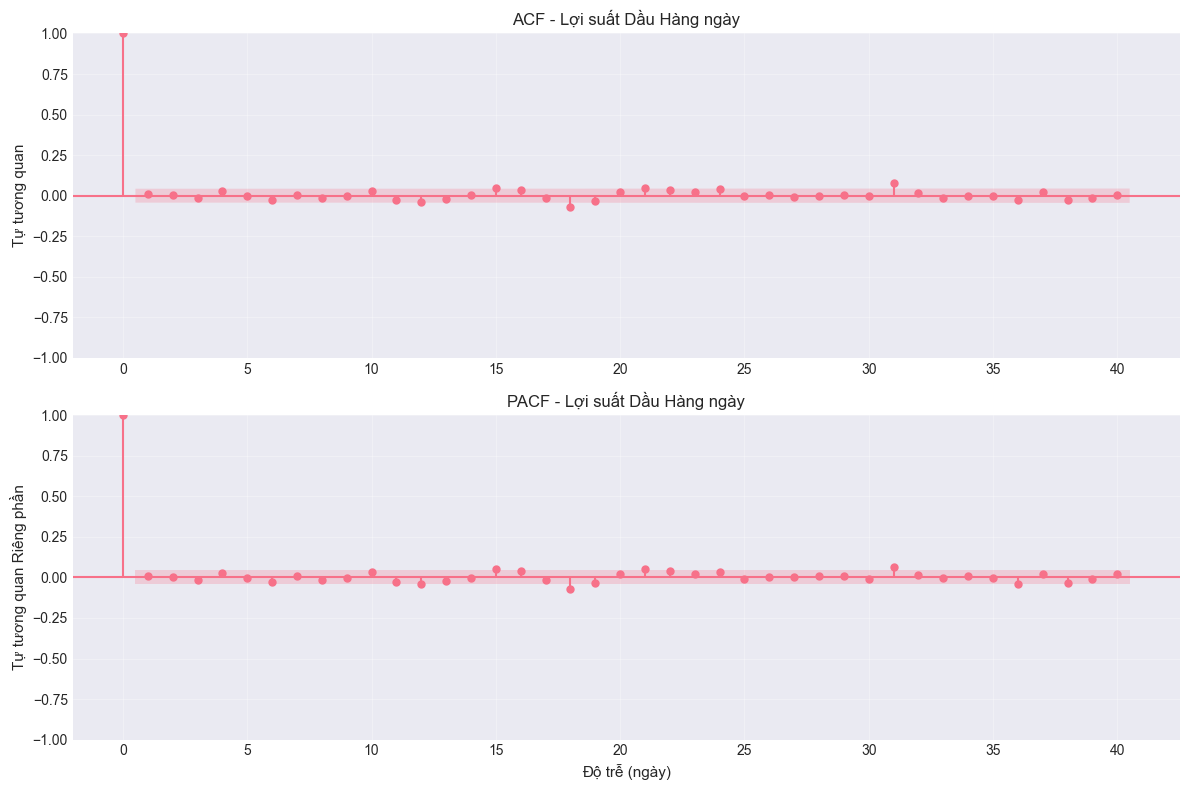


✓ Biểu đồ ACF/PACF hoàn tất
  → Nếu đa số đỉnh trong vùng xanh: nhiễu trắng (tốt cho chuỗi sai phân)
  → Đỉnh có ý nghĩa tại độ trễ 1: có thể là thành phần AR(1) hoặc cụm


In [6]:
# ACF/PACF cho oil_return
oil_ret_clean = df_train["oil_return"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Biểu đồ ACF
plot_acf(oil_ret_clean, lags=40, ax=axes[0], title="ACF - Lợi suất Dầu Hàng ngày")
axes[0].set_ylabel("Tự tương quan", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Biểu đồ PACF (tính toán nhiều hơn, nên giới hạn độ trễ)
plot_pacf(oil_ret_clean, lags=40, ax=axes[1], method="ywm", title="PACF - Lợi suất Dầu Hàng ngày")
axes[1].set_ylabel("Tự tương quan Riêng phần", fontsize=11)
axes[1].set_xlabel("Độ trễ (ngày)", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Biểu đồ ACF/PACF hoàn tất")
print("  → Nếu đa số đỉnh trong vùng xanh: nhiễu trắng (tốt cho chuỗi sai phân)")
print("  → Đỉnh có ý nghĩa tại độ trễ 1: có thể là thành phần AR(1) hoặc cụm")

## PHẦN 5: PHÂN TÍCH TƯƠNG QUAN TÍNH NĂNG (Spearman)

**Phương pháp:**
- **Tương quan Hạng Spearman:** ρ = 1 - (6Σd²)/(n(n²-1)), trong đó d = chênh lệch hạng
- **Tại sao Spearman?** Mạnh mẽ với ngoại lệ và quan hệ đơn điệu phi tuyến
- **Nhóm Tính năng:**
  - **Thị trường**: oil_close, oil_return, usd_close, sp500_close, vix
  - **Vĩ mô**: fed_rate, yield_spread, recession_signal, cpi_yoy, inflation, real_rate, fed_rate_regime, fed_rate_change
  - **Cung**: eia_crude_inventory, eia_production, eia_imports, inventory_zscore, production_change, imports_change
  - **Tâm lý**: gdelt_tone, gdelt_volume, gdelt_goldstein, gdelt_volume_log, gdelt_tone_spike, media_attention_spike, rolling_tone_ma, rolling_volume_ma
  - **Xung đột**: acled_conflict_count, acled_fatalities, conflict_intensity_7d, fatalities_7d
- **Độ trễ**: oil_return_lag1, oil_return_lag2
- **Dẫn xuất**: geopolitical_stress_index, oil_volatility_rolling
- **Ngưỡng:** |ρ| > 0.90 chỉ ra rủi ro đa cộng tuyến tiềm tàng

In [7]:
# Define feature groups for correlation analysis
feature_groups = {
    "Market": ["oil_close", "oil_return", "usd_close", "usd_return", "sp500_close", "sp500_return", 
               "vix_close", "vix_return", "vix_lag1"],
    "Macro": ["fed_funds_rate_lag", "yield_spread", "recession_signal", "cpi_yoy", "cpi_lag",
              "unemployment_lag", "real_rate", "fed_rate_regime", "fed_rate_change"],
    "Supply": ["crude_inventory_weekly", "crude_production_weekly", "net_imports_weekly", 
               "inventory_zscore", "production_change_pct", "net_imports_change_pct"],
    "Sentiment": ["gdelt_tone", "gdelt_volume", "gdelt_goldstein", "gdelt_events", "gdelt_volume_log",
                  "gdelt_tone_spike", "gdelt_tone_7d", "gdelt_goldstein_7d", "gdelt_volume_7d",
                  "gdelt_tone_lag1", "gdelt_volume_lag1", "media_attention_spike"],
    "Conflict": ["conflict_event_count", "fatalities", "conflict_intensity_7d", "fatalities_7d"],
    "Lags": ["oil_return_lag1", "oil_return_lag2"],
    "Derived": ["geopolitical_stress_index", "oil_volatility_7d", "stress_tone", "stress_volume", "stress_goldstein"],
    "Temporal": ["day_of_week", "month"]
}

# Flatten all features and filter for those present in df_train
all_features = [f for grp in feature_groups.values() for f in grp]
available_features = [f for f in all_features if f in df_train.columns]

print(f"\n{'='*80}")
print(f"PHẦN 5: PHÂN TÍCH TƯƠNG QUAN TÍNH NĂNG")
print(f"{'='*80}")
print(f"\nTổng tính năng để phân tích: {len(available_features)}")

# Tính tương quan Spearman cho mỗi nhóm so với mục tiêu
print(f"\n--- Tương quan Hạng Spearman với oil_return (Mục tiêu) ---\n")

correlations_by_group = {}
for group_name, features in feature_groups.items():
    group_features = [f for f in features if f in df_train.columns]
    if group_features:
        corrs = df_train[group_features].corrwith(df_train["oil_return"], method="spearman").sort_values(ascending=False)
        correlations_by_group[group_name] = corrs
        
        print(f"{group_name}:")
        for feat, rho in corrs.items():
            sig = "***" if abs(rho) > 0.90 else "**" if abs(rho) > 0.70 else "*" if abs(rho) > 0.50 else ""
            print(f"  {feat:30s} : {rho:7.4f} {sig}")
        print()

# Làm nổi bật các cặp đa cộng tuyến cao (trên tất cả tính năng)
print(f"--- Tính năng có Đa cộng tuyến Cao (|ρ| > 0.90) ---\n")
corr_matrix = df_train[available_features].corr(method="spearman")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.90:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], rho))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr_pairs:
    for feat1, feat2, rho in high_corr_pairs:
        print(f"  {feat1:30s} ↔ {feat2:30s} : ρ = {rho:7.4f}")
else:
    print("  Không phát hiện - không có cặp tính năng vượt ngưỡng 0.90")

print(f"\n✓ Phân tích tương quan hoàn tất")


PHẦN 5: PHÂN TÍCH TƯƠNG QUAN TÍNH NĂNG

Tổng tính năng để phân tích: 49

--- Tương quan Hạng Spearman với oil_return (Mục tiêu) ---

Market:
  oil_return                     :  1.0000 ***
  sp500_return                   :  0.2611 
  sp500_close                    :  0.0584 
  oil_close                      :  0.0554 
  vix_lag1                       :  0.0177 
  vix_close                      : -0.0326 
  usd_close                      : -0.0540 
  usd_return                     : -0.1215 
  vix_return                     : -0.2331 

Macro:
  unemployment_lag               :  0.0389 
  cpi_lag                        :  0.0358 
  cpi_yoy                        :  0.0075 
  yield_spread                   : -0.0007 
  recession_signal               : -0.0068 
  fed_rate_regime                : -0.0267 
  real_rate                      : -0.0284 
  fed_rate_change                : -0.0478 
  fed_funds_rate_lag             : -0.0528 

Supply:
  crude_production_weekly        : -0.0000 
  

## PHẦN 6: TƯƠNG QUAN TÍNH NĂNG NHỊ PHÂN (Điểm Song sát)

**Phương pháp:**
- **Tương quan Điểm Song sát (r_pb):** Tương quan giữa biến nhị phân và liên tục
  $$r_{pb} = \frac{M_1 - M_0}{SD} \sqrt{\frac{n_1 n_0}{n^2}}$$
  trong đó M₁/M₀ = trung bình cho các nhóm nhị phân, SD = độ lệch chuẩn hợp nhất
- **Tính năng Nhị phân:**
  - recession_signal: 1 nếu yield_spread < 0 (đường cong đảo ngược), nếu không là 0
  - gdelt_tone_spike: 1 nếu tone < rolling_tone_30d - 1 (sự sụt âm), nếu không là 0  
  - media_attention_spike: 1 nếu volume > percentile 95 rolling, nếu không là 0
- **Giải thích:** |r_pb| > 0.3 chỉ ra hiệp hội có ý nghĩa với oil_return
- **Trường hợp Sử dụng:** Xác định các tính năng dựa trên sự kiện báo hiệu chuyển động giá dầu

In [8]:
# Xác định các tính năng nhị phân (chỉ giá trị 0/1)
binary_features = []
for col in df_train.columns:
    if col not in ["oil_return"]:  # Bỏ qua mục tiêu
        unique_vals = df_train[col].dropna().unique()
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_features.append(col)

print(f"\n--- Tương quan Điểm Song sát (Nhị phân vs Mục tiêu Liên tục) ---\n")
print(f"Tính năng nhị phân tìm thấy: {len(binary_features)}")
print(f"  {', '.join(binary_features)}\n")

# Tính toán tương quan điểm song sát cho các tính năng nhị phân
binary_corrs = {}
for feat in binary_features:
    if feat in df_train.columns:
        # Sử dụng tương quan Pearson làm proxy cho điểm song sát
        # (tương đương toán học cho biến nhị phân 0/1 và liên tục)
        corr = scipy.stats.pointbiserialr(df_train[feat].dropna(), 
                                          df_train.loc[df_train[feat].notna(), "oil_return"])[0]
        binary_corrs[feat] = corr

if binary_corrs:
    sorted_binary = sorted(binary_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
    for feat, r_pb in sorted_binary:
        sig = "***" if abs(r_pb) > 0.50 else "**" if abs(r_pb) > 0.30 else "*" if abs(r_pb) > 0.15 else ""
        indicator = "→ YẾU" if abs(r_pb) < 0.15 else "→ TRUNG" if abs(r_pb) < 0.30 else "→ MẠNH"
        print(f"  {feat:30s} : r_pb = {r_pb:7.4f} {sig:3s} {indicator}")
else:
    print("  Không có tính năng nhị phân khả dụng để phân tích")

print(f"\n✓ Phân tích tương quan tính năng nhị phân hoàn tất")


--- Tương quan Điểm Song sát (Nhị phân vs Mục tiêu Liên tục) ---

Tính năng nhị phân tìm thấy: 4
  gdelt_tone_spike, gdelt_data_imputed, recession_signal, media_attention_spike

  media_attention_spike          : r_pb =  0.0191     → YẾU
  recession_signal               : r_pb = -0.0136     → YẾU
  gdelt_data_imputed             : r_pb =  0.0087     → YẾU
  gdelt_tone_spike               : r_pb = -0.0077     → YẾU

✓ Phân tích tương quan tính năng nhị phân hoàn tất


## PHẦN 7: BẢN ĐỒ TƯƠNG QUAN (Phát hiện Đa cộng tuyến)

**Phương pháp:**
- **Hình ảnh hóa:** 4 bản đồ tương quan riêng cho mỗi nhóm tính năng + tính năng dẫn xuất
- **Mã hóa Màu:** 
  - Phổ Xanh/Đỏ: -1 (liên hệ âm hoàn toàn) đến +1 (liên hệ dương hoàn toàn)
  - Trắng ≈ 0 (không có tương quan)
- **Ngưỡng Đa cộng tuyến:**
  - |ρ| > 0.90: NGUY HIỂM - xem xét loại bỏ một tính năng
  - 0.70 < |ρ| ≤ 0.90: VỪA - theo dõi VIF > 10
  - |ρ| ≤ 0.70: CÓ THỂ CHẤP NHẬN với hầu hết ứng dụng
- **VIF (Hệ số Lạm phát Phương sai):** VIF_i = 1/(1-R²_i) trong đó R² từ hồi quy tính năng i với các tính năng khác
  - VIF > 10: Đa cộng tuyến Nghiêm trọng → loại bỏ tính năng
  - VIF 5-10: Đa cộng tuyến Vừa → xem xét loại bỏ
- **Quy tắc Quyết định:** Loại bỏ tính năng nếu ρ > 0.90 với tính năng khác, giữ lại cái có tương quan cao hơn với mục tiêu

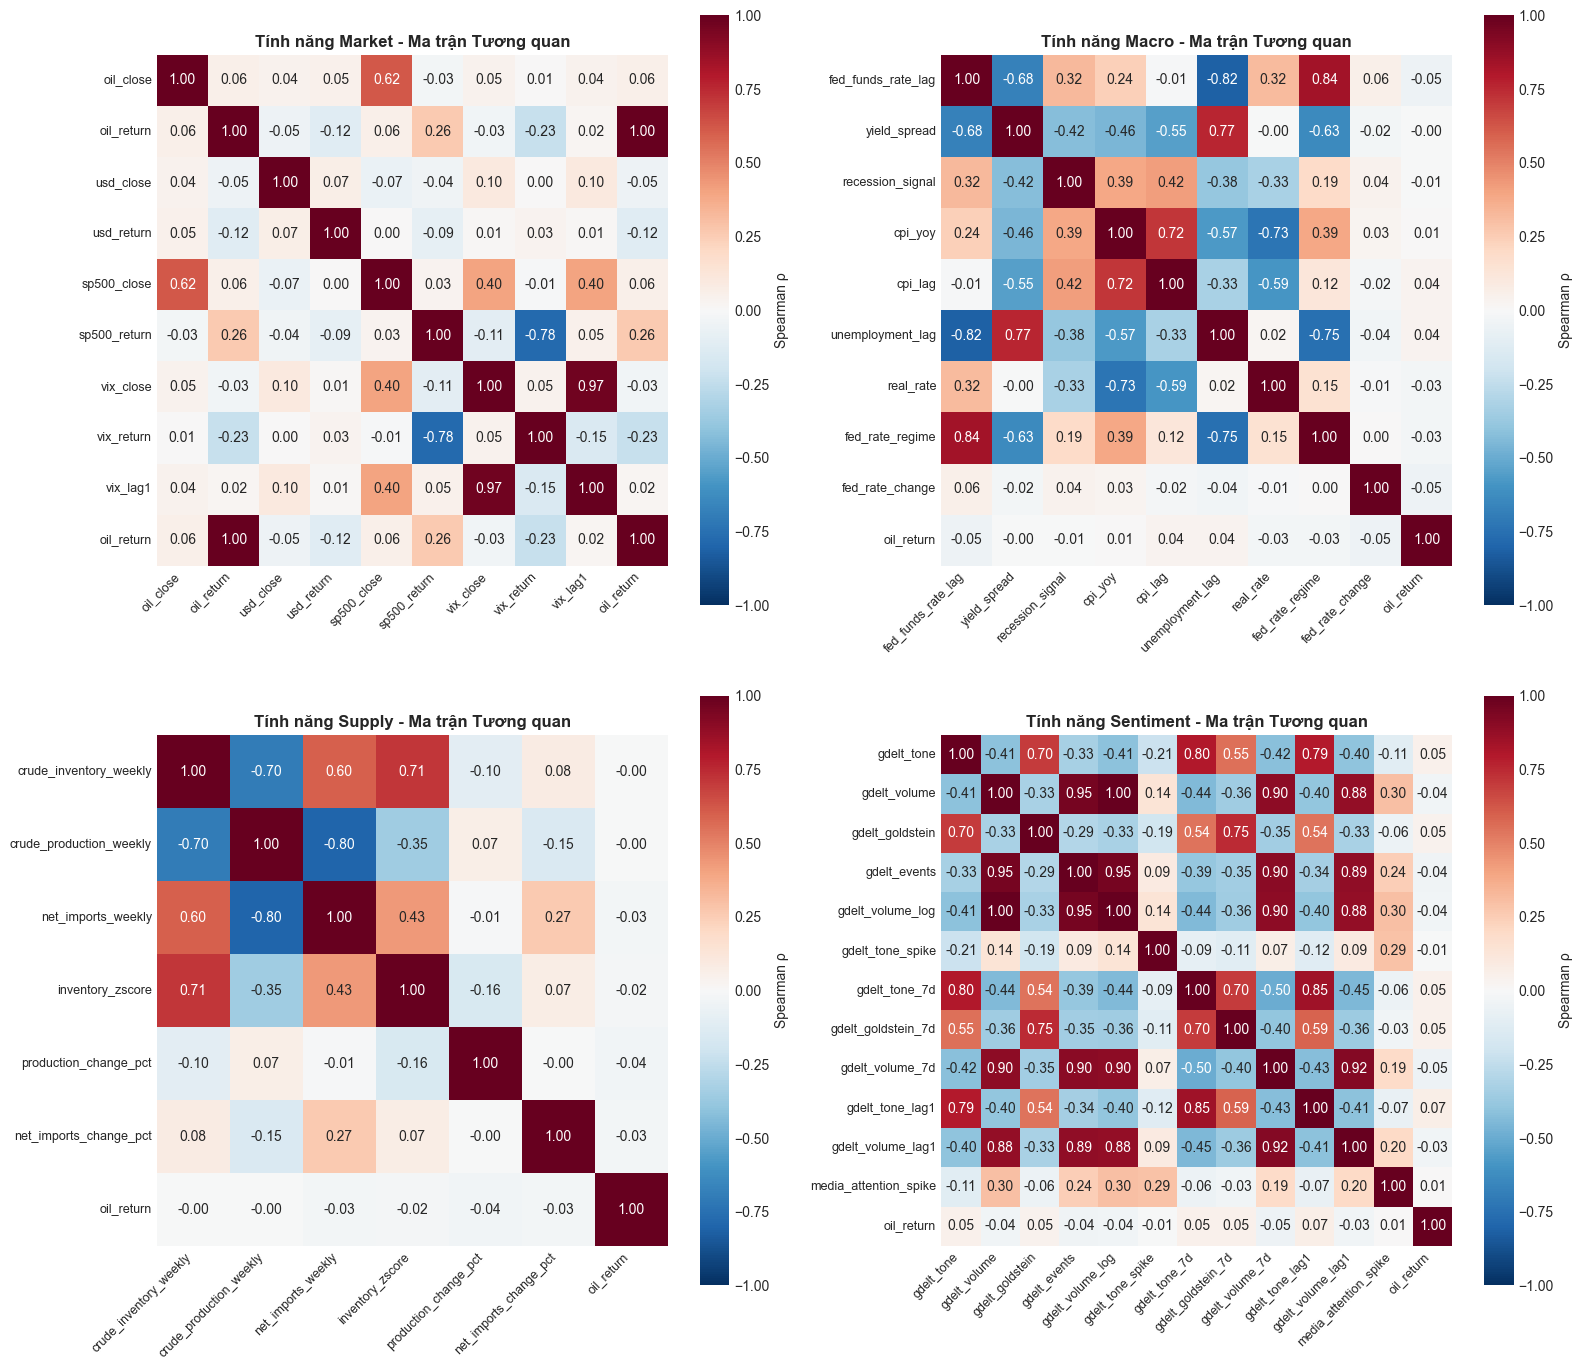


⏳ Tạo thêm heatmap cho Supply & Conflict...



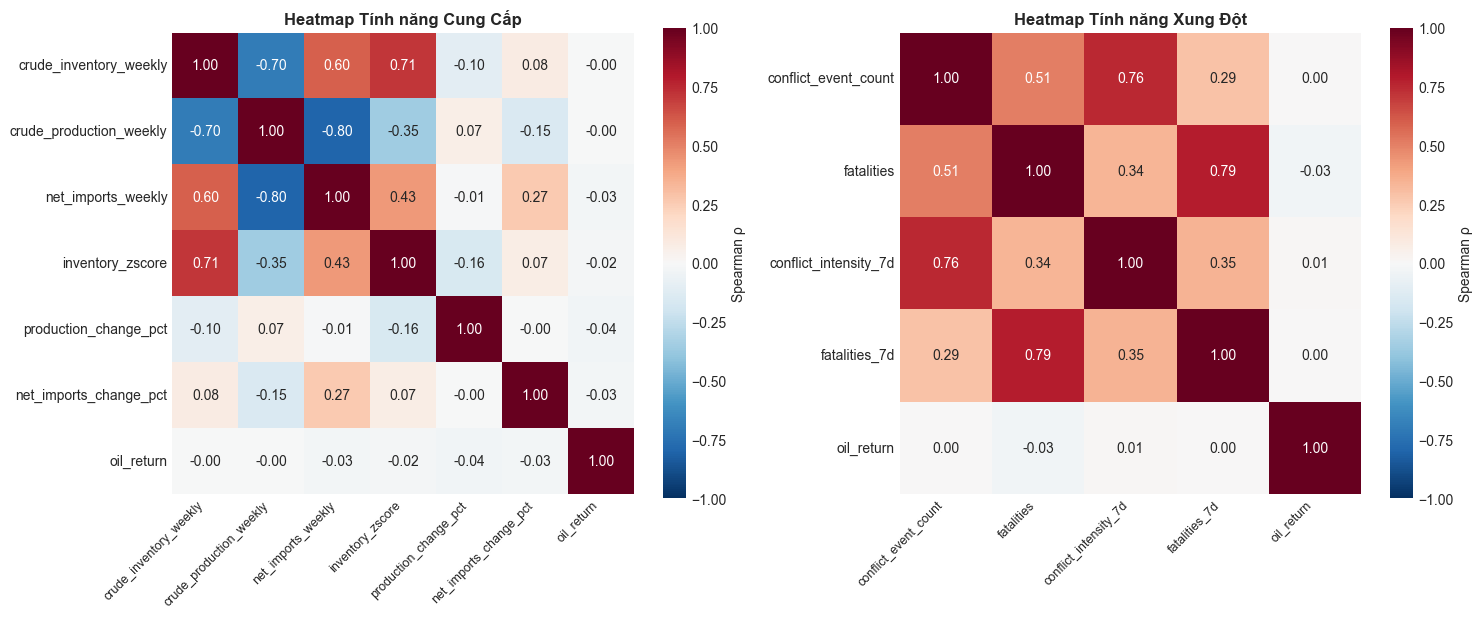


--- Đánh giá Đa cộng tuyến ---

⏳ Tạo boxplots cho các nhóm features...



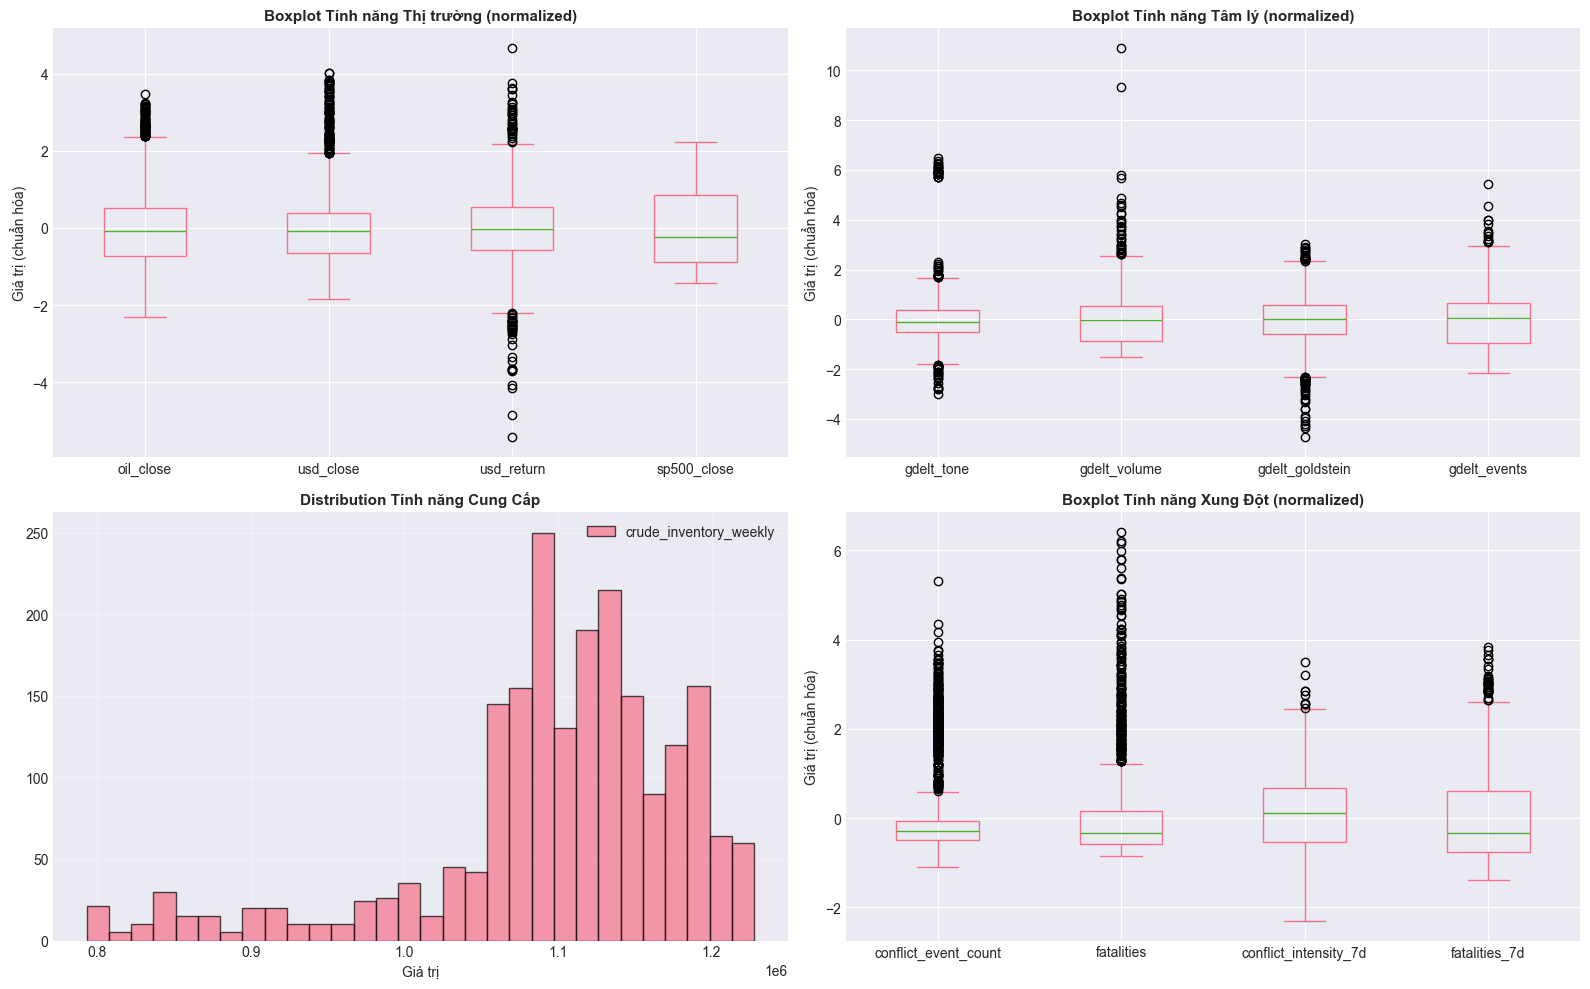

✓ Boxplots & Distribution plots hoàn tất

Market - Hệ số Lạm phát Phương sai:
  vix_close                      : VIF =  851.29 ⚠ NGUY HIỂM
  vix_lag1                       : VIF =  835.27 ⚠ NGUY HIỂM
  sp500_close                    : VIF =   28.44 ⚠ NGUY HIỂM
  oil_close                      : VIF =   24.14 ⚠ NGUY HIỂM
  usd_close                      : VIF =   21.11 ⚠ NGUY HIỂM
  vix_return                     : VIF =    5.89 ⚡ VỪA
  sp500_return                   : VIF =    2.81 ✓ OK
  oil_return                     : VIF =    1.11 ✓ OK
  usd_return                     : VIF =    1.04 ✓ OK

Macro - Hệ số Lạm phát Phương sai:
  fed_funds_rate_lag             : VIF =     inf ⚠ NGUY HIỂM
  cpi_yoy                        : VIF =     inf ⚠ NGUY HIỂM
  real_rate                      : VIF =     inf ⚠ NGUY HIỂM
  cpi_lag                        : VIF =  113.75 ⚠ NGUY HIỂM
  unemployment_lag               : VIF =   21.77 ⚠ NGUY HIỂM
  yield_spread                   : VIF =   12.85 ⚠ NGUY HIỂ

In [24]:
# Tạo 4 bản đồ tương quan cho các nhóm tính năng
groups_to_plot = ["Market", "Macro", "Supply", "Sentiment"]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (group_name, features) in enumerate([
    (g, feature_groups[g]) for g in groups_to_plot if g in feature_groups
]):
    group_features = [f for f in features if f in df_train.columns]
    
    if group_features:
        # Đưa vào mục tiêu để tham chiếu tương quan
        plot_features = group_features + ["oil_return"]
        corr_matrix = df_train[plot_features].corr(method="spearman")
        
        # Tạo bản đồ tương quan
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    cbar_kws={"label": "Spearman ρ"}, ax=axes[idx], 
                    vmin=-1, vmax=1, square=True)
        axes[idx].set_title(f"Tính năng {group_name} - Ma trận Tương quan", fontsize=12, fontweight="bold")
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right", fontsize=9)
        axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# --- Thêm heatmap cho Supply & Conflict ---
print("\n⏳ Tạo thêm heatmap cho Supply & Conflict...\n")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Supply heatmap
if "Supply" in feature_groups:
    supply_features = [f for f in feature_groups["Supply"] if f in df_train.columns]
    if supply_features:
        plot_features = supply_features + ["oil_return"]
        corr_supply = df_train[plot_features].corr(method="spearman")
        sns.heatmap(corr_supply, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    ax=axes[0], vmin=-1, vmax=1, square=True, 
                    cbar_kws={"label": "Spearman ρ"})
        axes[0].set_title("Heatmap Tính năng Cung Cấp", fontsize=12, fontweight="bold")
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=9)

# Conflict heatmap
if "Conflict" in feature_groups:
    conflict_features = [f for f in feature_groups["Conflict"] if f in df_train.columns]
    if conflict_features:
        plot_features = conflict_features + ["oil_return"]
        corr_conflict = df_train[plot_features].corr(method="spearman")
        sns.heatmap(corr_conflict, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    ax=axes[1], vmin=-1, vmax=1, square=True,
                    cbar_kws={"label": "Spearman ρ"})
        axes[1].set_title("Heatmap Tính năng Xung Đột", fontsize=12, fontweight="bold")
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

print("\n--- Đánh giá Đa cộng tuyến ---\n")

# --- Thêm Boxplots cho Market & Sentiment features ---
print("⏳ Tạo boxplots cho các nhóm features...\n")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Market boxplots
market_features = [f for f in feature_groups["Market"] if f in df_train.columns and f != "oil_return"][:4]
if market_features and len(market_features) > 0:
    df_plot = df_train[market_features].copy()
    df_plot = (df_plot - df_plot.mean()) / df_plot.std()  # Chuẩn hóa
    df_plot.plot(kind='box', ax=axes[0, 0], grid=True)
    axes[0, 0].set_title("Boxplot Tính năng Thị trường (normalized)", fontsize=11, fontweight="bold")
    axes[0, 0].set_ylabel("Giá trị (chuẩn hóa)")

# Sentiment boxplots
sentiment_core = [f for f in feature_groups["Sentiment"] if f in df_train.columns][:4]
if sentiment_core and len(sentiment_core) > 0:
    df_plot = df_train[sentiment_core].copy()
    df_plot = (df_plot - df_plot.mean()) / df_plot.std()
    df_plot.plot(kind='box', ax=axes[0, 1], grid=True)
    axes[0, 1].set_title("Boxplot Tính năng Tâm lý (normalized)", fontsize=11, fontweight="bold")
    axes[0, 1].set_ylabel("Giá trị (chuẩn hóa)")

# Supply distribution
supply_features = [f for f in feature_groups["Supply"] if f in df_train.columns][:3]
if supply_features:
    for col in supply_features[:1]:
        axes[1, 0].hist(df_train[col].dropna(), bins=30, alpha=0.7, label=col, edgecolor='black')
    axes[1, 0].set_title("Distribution Tính năng Cung Cấp", fontsize=11, fontweight="bold")
    axes[1, 0].set_xlabel("Giá trị")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Conflict boxplots
conflict_features = [f for f in feature_groups["Conflict"] if f in df_train.columns]
if conflict_features:
    df_plot = df_train[conflict_features].copy()
    df_plot = (df_plot - df_plot.mean()) / df_plot.std()
    df_plot.plot(kind='box', ax=axes[1, 1], grid=True)
    axes[1, 1].set_title("Boxplot Tính năng Xung Đột (normalized)", fontsize=11, fontweight="bold")
    axes[1, 1].set_ylabel("Giá trị (chuẩn hóa)")

plt.tight_layout()
plt.show()

print("✓ Boxplots & Distribution plots hoàn tất\n")

# Tính VIF cho mỗi nhóm
from statsmodels.stats.outliers_influence import variance_inflation_factor

for group_name, features in [(g, feature_groups[g]) for g in groups_to_plot]:
    group_features = [f for f in features if f in df_train.columns]
    
    if group_features and len(group_features) > 1:  # Chỉ VIF cho 2+ tính năng
        # Chuẩn bị dữ liệu (xử lý NaN)
        X_group = df_train[group_features].dropna(axis=0)
        
        if len(X_group) > 0:
            vif_data = pd.DataFrame()
            vif_data["Feature"] = X_group.columns
            vif_data["VIF"] = [variance_inflation_factor(X_group.values, i) 
                              for i in range(X_group.shape[1])]
            vif_data = vif_data.sort_values("VIF", ascending=False)
            
            print(f"{group_name} - Hệ số Lạm phát Phương sai:")
            for _, row in vif_data.iterrows():
                vif_val = row["VIF"]
                sig = "⚠ NGUY HIỂM" if vif_val > 10 else "⚡ VỪA" if vif_val > 5 else "✓ OK" if vif_val < 3 else ""
                print(f"  {row['Feature']:30s} : VIF = {vif_val:7.2f} {sig}")
            print()
    elif group_features:
        print(f"{group_name} - Hệ số Lạm phát Phương sai:")
        print(f"  (Chỉ {len(group_features)} tính năng - VIF không áp dụng)")
        print()

print(f"\n✓ Phân tích bản đồ tương quan và VIF hoàn tất")

## PHẦN 8: PHÂN TÍCH TƯƠNG QUAN ROLLING (Mối quan hệ Động)

**Phương pháp:**
- **Tương quan Spearman Rolling:** ρ_t(y_t, x_t) tính toán trên các cửa sổ 90 ngày
  $$\rho_t = \text{Spearman}(y_{t-89:t}, x_{t-89:t})$$
- **Mục tiêu:** Phát hiện những thay đổi chế độ nơi tầm quan trọng của tính năng thay đổi theo thời gian
- **Chú thích Sự kiện:**
  - **Sốc COVID-19** (2020-03-01 đến 2020-05-01): Giá dầu sụp đổ, các yếu tố địa chính trị mất liên hệ
  - **Cuộc xâm lược Ukraine** (2022-02-24 trở đi): Sốc cung, phí địa chính trị tăng vọt
  - **Xung đột Gaza** (2023-10-07 trở đi): Escalation khu vực, giá dầu bền vững
- **Những hiểu biết Chính cần Tìm:**
  - Tương quan với VIX/cung có tăng trong những cuộc khủng hoảng không?
  - geopolitical_stress_index có trở nên dự báo hơn không?
  - Tương quan có ổn định trong chế độ bình thường không?


PHÂN TÍCH TƯƠNG QUAN ROLLING 90 NGÀY

Tính năng chính được phân tích: vix_close, crude_inventory_weekly, gdelt_volume_log, geopolitical_stress_index, fed_funds_rate_lag, usd_close



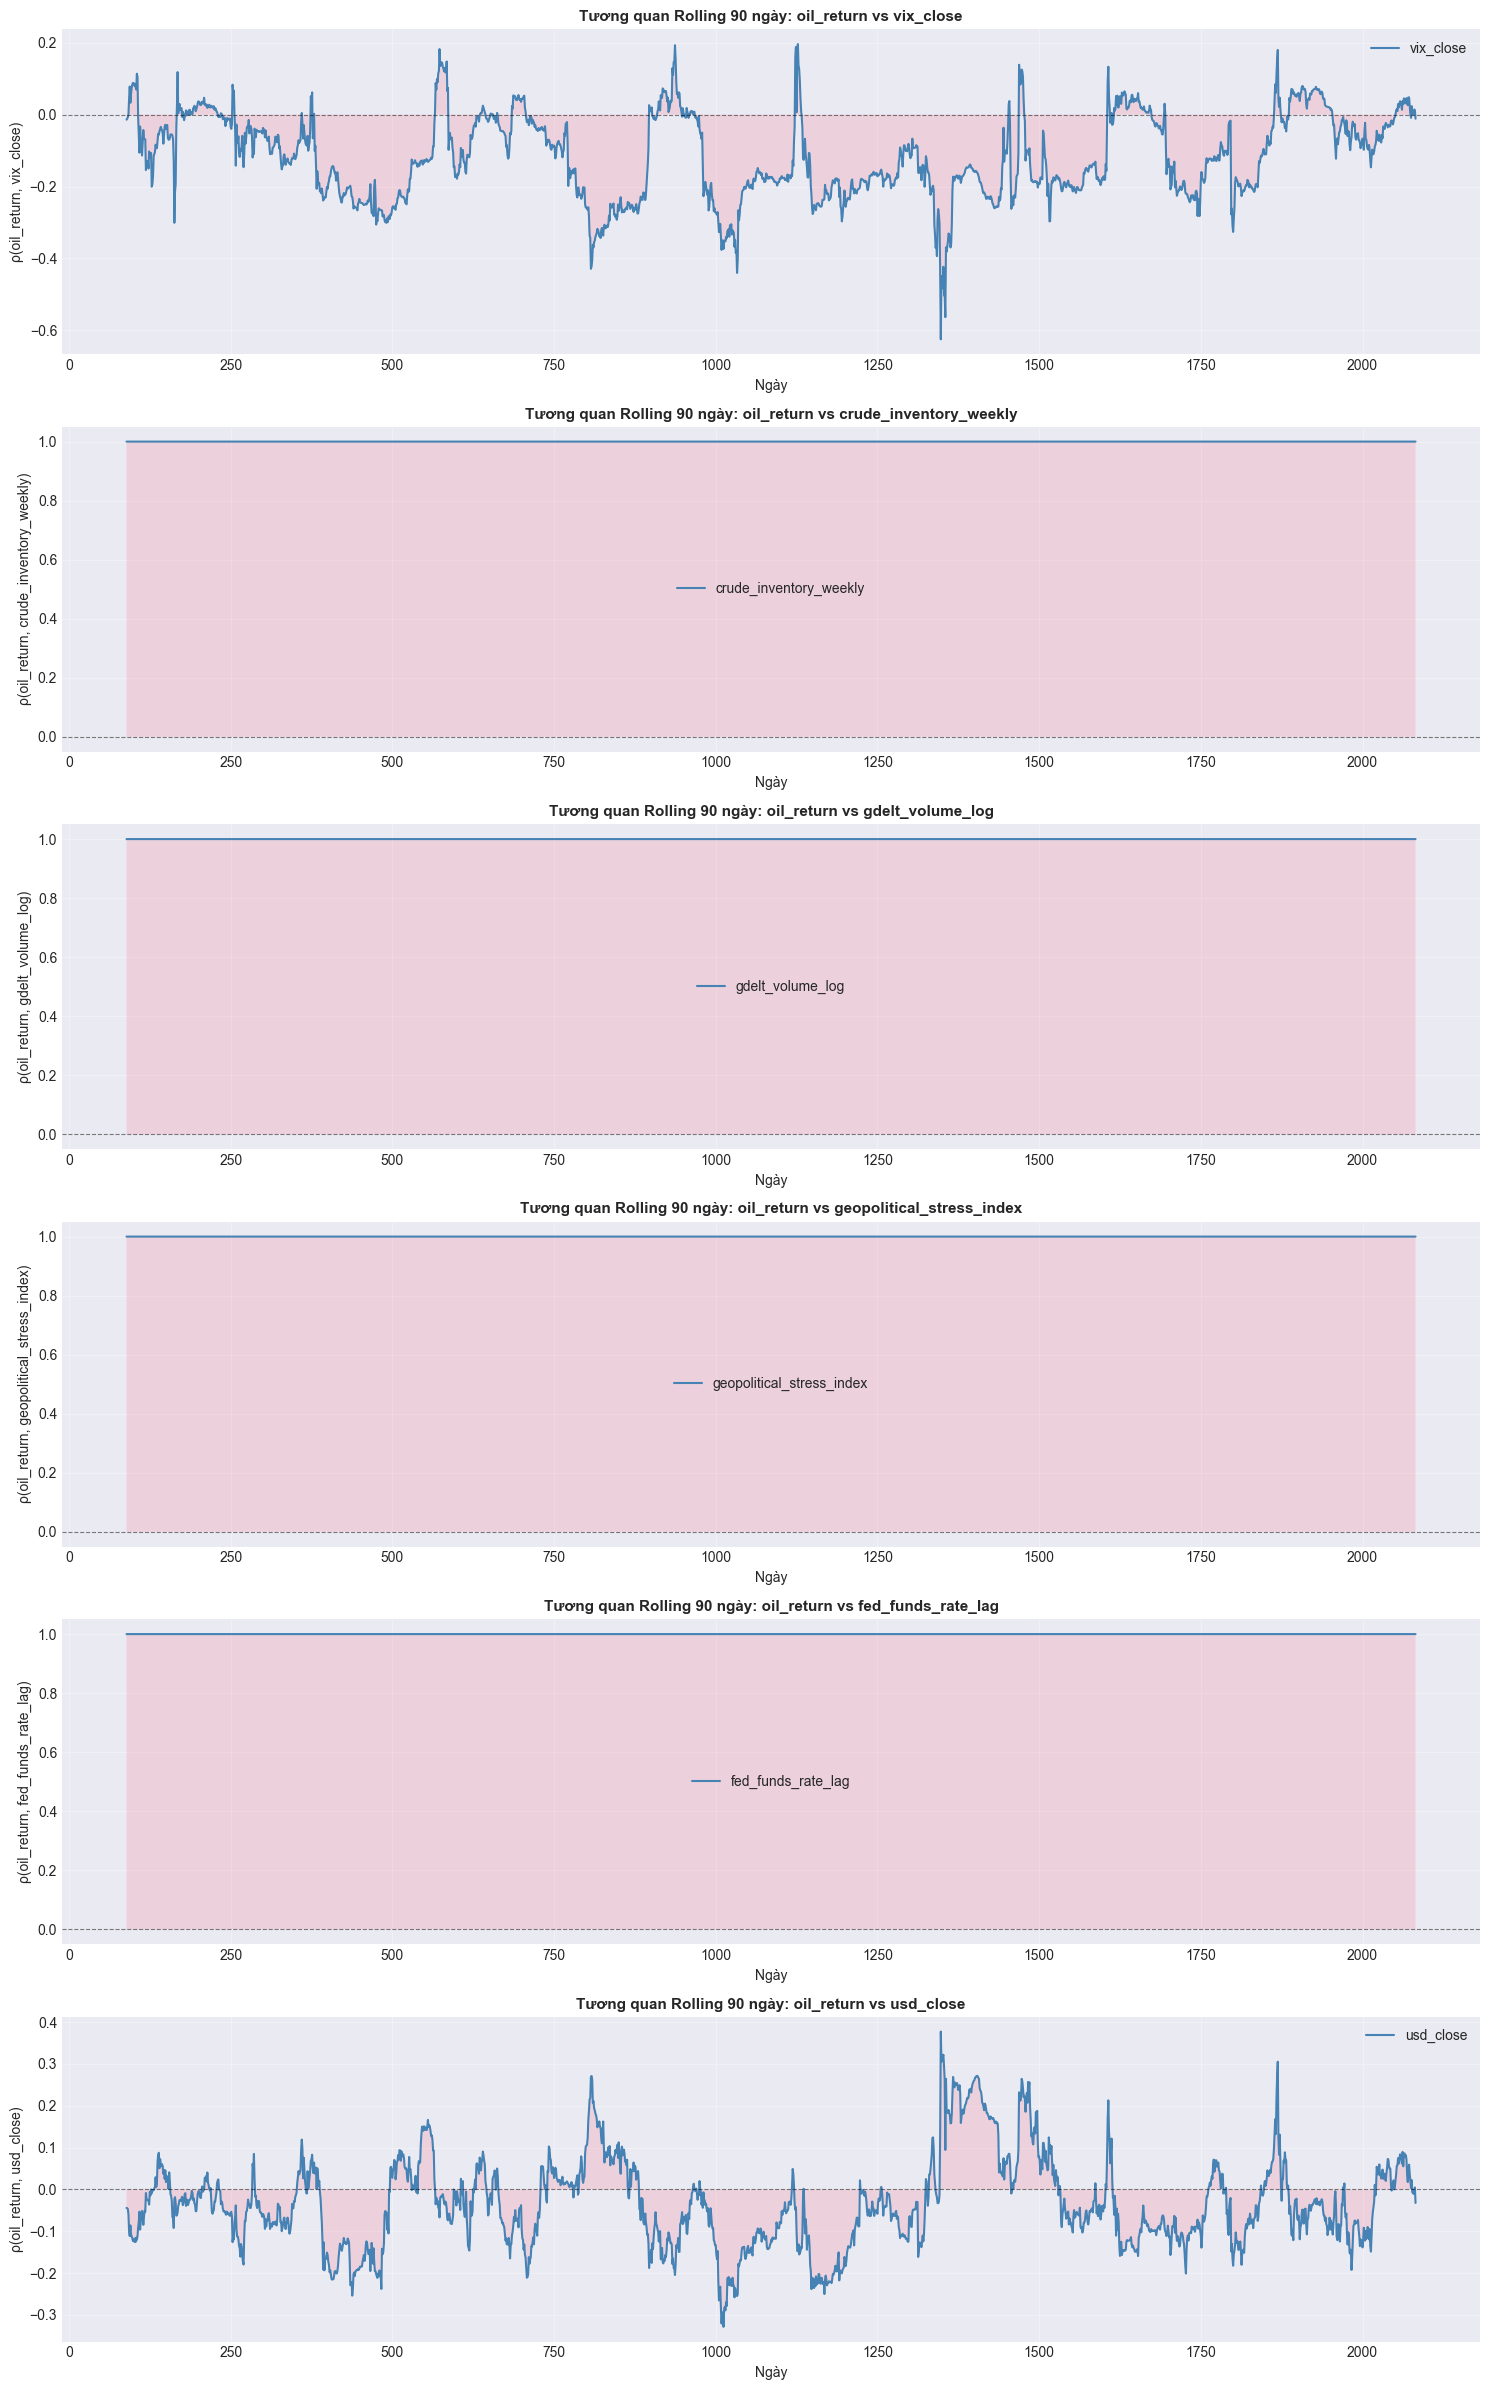

✓ Biểu đồ tương quan rolling được tạo
  → Vùng trên: tương quan dương (tính năng di chuyển theo giá dầu)
  → Vùng dưới: tương quan âm (tính năng di chuyển ngược giá dầu)
  → Gãy chế độ tại các sự kiện chỉ ra các gãy cấu trúc trong mối quan hệ


In [25]:
# Chọn các tính năng chính cho phân tích tương quan rolling
key_features_rolling = ["vix_close", "crude_inventory_weekly", "gdelt_volume_log", 
                        "geopolitical_stress_index", "fed_funds_rate_lag", "usd_close"]

# Lọc các tính năng có trong df_train
key_features_available = [f for f in key_features_rolling if f in df_train.columns]

print(f"\nPHÂN TÍCH TƯƠNG QUAN ROLLING 90 NGÀY\n")
print(f"Tính năng chính được phân tích: {', '.join(key_features_available)}\n")

# Tính tương quan rolling
rolling_window = 90
fig, axes = plt.subplots(len(key_features_available), 1, figsize=(15, 4*len(key_features_available)))
if len(key_features_available) == 1:
    axes = [axes]

# Định nghĩa các sự kiện địa chính trị chính để chú thích
events = [
    ("2020-03-01", "Sốc COVID-19"),
    ("2022-02-24", "Cuộc xâm lược Ukraine"),
    ("2023-10-07", "Xung đột Gaza")
]

for idx, feat in enumerate(key_features_available):
    # Tính tương quan rolling
    rolling_corr = df_train[["oil_return", feat]].rolling(window=rolling_window).corr().unstack().iloc[:, 1]
    
    axes[idx].plot(rolling_corr.index, rolling_corr.values, linewidth=1.5, color="steelblue", label=feat)
    axes[idx].axhline(y=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    axes[idx].fill_between(rolling_corr.index, 0, rolling_corr.values, alpha=0.2)
    
    # Chú thích sự kiện
    for event_date, event_name in events:
        try:
            evt_date = pd.Timestamp(event_date)
            if evt_date in df_train.index:
                axes[idx].axvline(x=evt_date, color="red", linestyle=":", alpha=0.5)
                axes[idx].text(evt_date, axes[idx].get_ylim()[1]*0.9, event_name, 
                             rotation=0, fontsize=9, ha="center", color="red")
        except:
            pass
    
    axes[idx].set_ylabel(f"ρ(oil_return, {feat})", fontsize=10)
    axes[idx].set_xlabel("Ngày", fontsize=10)
    axes[idx].set_title(f"Tương quan Rolling 90 ngày: oil_return vs {feat}", fontsize=11, fontweight="bold")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc="best")

plt.tight_layout()
plt.show()

print(f"✓ Biểu đồ tương quan rolling được tạo")
print(f"  → Vùng trên: tương quan dương (tính năng di chuyển theo giá dầu)")
print(f"  → Vùng dưới: tương quan âm (tính năng di chuyển ngược giá dầu)")
print(f"  → Gãy chế độ tại các sự kiện chỉ ra các gãy cấu trúc trong mối quan hệ")

## PHẦN 9: PHÁT HIỆN NGOẠI LỆ (Phương pháp IQR)

**Phương pháp:**
- **Khoảng Tứ phân vị (IQR):** IQR = Q₃ - Q₁ (percentile thứ 75 - thứ 25)
- **Định nghĩa Ngoại lệ (Quy tắc 1.5×IQR):**
  - Giới hạn Dưới: Q₁ - 1.5×IQR
  - Giới hạn Trên: Q₃ + 1.5×IQR
  - Các điểm ngoài giới hạn được đánh dấu là ngoại lệ
- **Ngoại lệ Cực kỳ (Quy tắc 3×IQR):**
  - Giới hạn Dưới: Q₁ - 3×IQR
  - Giới hạn Trên: Q₃ + 3×IQR
- **Xác thực Dựa trên Sự kiện Đã biết:**
  - Sốc COVID-19 (2020-03): oil_return có thể -50%, kiểm tra điều này
  - Chiến tranh Ukraine (2022-02): WTI tăng đến $100+, đỉnh geopolitical_stress_index
  - Vận hành bình thường: ngoại lệ nên hiếm (~<2% dữ liệu)
- **Quyết định:** Giữ ngoại lệ trừ khi chúng đại diện cho lỗi dữ liệu (không phải hành vi dự kiến của các chuyên gia)

In [26]:
# Phát hiện ngoại lệ cho các tính năng số chính
key_features_outliers = ["oil_return", "oil_volatility_7d", "vix_close", 
                         "gdelt_volume_log", "geopolitical_stress_index", 
                         "crude_inventory_weekly"]

print(f"\nPHÁT HIỆN NGOẠI LỆ (Phương pháp IQR - 1.5×IQR)\n")
print(f"{'Tính năng':<30} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Dưới':>10} {'Trên':>10} {'Số':>8} {'%':>6}\n")

outlier_summary = {}

for feat in key_features_outliers:
    if feat in df_train.columns:
        data = df_train[feat].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        
        outliers = ((data < lower) | (data > upper)).sum()
        pct = 100 * outliers / len(data)
        
        outlier_summary[feat] = {
            "count": outliers, "pct": pct, "lower": lower, "upper": upper, 
            "Q1": Q1, "Q3": Q3, "IQR": IQR, "min": data.min(), "max": data.max()
        }
        
        print(f"{feat:<30} {Q1:>8.4f} {Q3:>8.4f} {IQR:>8.4f} {lower:>10.4f} {upper:>10.4f} {outliers:>8d} {pct:>6.2f}%")

# Xác định ngoại lệ cực kỳ (Quy tắc 3×IQR)
print(f"\n--- Ngoại lệ Cực kỳ (Quy tắc 3×IQR) ---\n")
for feat in key_features_outliers:
    if feat in df_train.columns:
        data = df_train[feat].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_ext = Q1 - 3*IQR
        upper_ext = Q3 + 3*IQR
        
        extreme = ((data < lower_ext) | (data > upper_ext)).sum()
        if extreme > 0:
            print(f"{feat:<30} : {extreme:>3d} ngoại lệ cực kỳ")

print(f"\n✓ Phân tích ngoại lệ hoàn tất - Giữ tất cả ngoại lệ (đại diện cho sự kiện thị trường thực tế)")


PHÁT HIỆN NGOẠI LỆ (Phương pháp IQR - 1.5×IQR)

Tính năng                            Q1       Q3      IQR       Dưới       Trên       Số      %

oil_return                      -0.0106   0.0126   0.0232    -0.0455     0.0474      135   6.48%
oil_volatility_7d                0.0120   0.0243   0.0123    -0.0065     0.0427      103   4.94%
vix_close                       13.2000  22.4750   9.2750    -0.7125    36.3875       49   2.35%
gdelt_volume_log                11.2289  12.2914   1.0625     9.6352    13.8851        7   0.34%
geopolitical_stress_index        0.5092   0.6217   0.1125     0.3404     0.7905       35   1.68%
crude_inventory_weekly         1069976.0000 1150226.0000 80250.0000 949601.0000 1270601.0000      156   7.49%

--- Ngoại lệ Cực kỳ (Quy tắc 3×IQR) ---

oil_return                     :  28 ngoại lệ cực kỳ
oil_volatility_7d              :  39 ngoại lệ cực kỳ
vix_close                      :  18 ngoại lệ cực kỳ
geopolitical_stress_index      :   1 ngoại lệ cực kỳ
crude

## PHẦN 10: BẢNG THỐNG KÊ TÓM TẮT

**Mục tiêu:** Tài liệu tham khảo nguồn đơn cho tất cả các tính năng được phân tích với các thuộc tính thống kê chính

**Cột:**
- **Tính năng**: Tên biến
- **Trung bình/SD**: Xu hướng trung tâm và độ phân tán
- **Skew/Kurt**: Hình dạng phân phối (Skew |>1| chỉ ra bất đối xứng, Kurt >3 chỉ ra đuôi nặng)
- **Min/Max**: Phạm vi giá trị
- **Thiếu%**: Tính đầy đủ của dữ liệu
- **Corr(oil_return)**: Tương quan Spearman với mục tiêu
- **Loại**: Mô tả phân loại (Thị trường, Vĩ mô, Cung, Tâm lý, Xung đột, Dẫn xuất)
- **Cờ**: Ghi chú về đa cộng tuyến, dữ liệu thiếu hoặc vấn đề đo lường

In [27]:
# Tạo bảng tóm tắt tính năng toàn diện cho luận văn
print(f"\nBẢNG THỐNG KÊ TÍNH NĂNG TÓM TẮT TOÀN DIỆN\n")
print(f"Kích thước Tập Train: {len(df_train)} quan sát\n")

summary_data = []

# Định nghĩa ánh xạ tính năng-nhóm
feature_type_map = {}
for group_name, features in feature_groups.items():
    for feat in features:
        feature_type_map[feat] = group_name

# Xử lý tất cả tính năng
for col in df_train.columns:
    if col not in ["oil_return", "date"]:  # Bỏ qua mục tiêu và ngày
        series = df_train[col].dropna()
        
        # Chỉ xử lý các cột số
        if pd.api.types.is_numeric_dtype(series):
            if len(series) > 0:
                mean_val = series.mean()
                sd_val = series.std()
                skew_val = series.skew()
                kurt_val = series.kurtosis()
                min_val = series.min()
                max_val = series.max()
                missing_pct = 100 * (1 - len(series) / len(df_train))
                
                # Correlation with target
                if col in correlations_by_group.get("Market", {}).index:
                    corr_target = correlations_by_group["Market"][col]
                elif col in correlations_by_group.get("Macro", {}).index:
                    corr_target = correlations_by_group["Macro"][col]
                elif col in correlations_by_group.get("Supply", {}).index:
                    corr_target = correlations_by_group["Supply"][col]
                elif col in correlations_by_group.get("Sentiment", {}).index:
                    corr_target = correlations_by_group["Sentiment"][col]
                elif col in correlations_by_group.get("Conflict", {}).index:
                    corr_target = correlations_by_group["Conflict"][col]
                elif col in correlations_by_group.get("Lags", {}).index:
                    corr_target = correlations_by_group["Lags"][col]
                elif col in correlations_by_group.get("Derived", {}).index:
                    corr_target = correlations_by_group["Derived"][col]
                else:
                    corr_target = df_train[[col, "oil_return"]].corr(method="spearman").iloc[0, 1]
                
                # Determine flags
                flags = []
                if missing_pct > 1:
                    flags.append(f"Missing:{missing_pct:.1f}%")
                if abs(skew_val) > 1:
                    flags.append(f"Skewed:{skew_val:.2f}")
                if col in [f[0] or f[1] for f in high_corr_pairs]:
                    flags.append("Multicollinear")
                
                feature_type = feature_type_map.get(col, "Other")
                
                summary_data.append({
                    "Feature": col,
                    "Mean": mean_val,
                    "SD": sd_val,
                    "Skew": skew_val,
                    "Kurt": kurt_val,
                    "Min": min_val,
                    "Max": max_val,
                    "Missing%": missing_pct,
                    "Corr(target)": corr_target,
                    "Type": feature_type,
                    "Flags": "; ".join(flags) if flags else "OK"
                })

# Tạo DataFrame và hiển thị
summary_df = pd.DataFrame(summary_data).sort_values("Corr(target)", key=abs, ascending=False)

# Hiển thị 25 tính năng hàng đầu
print("=" * 130)
print(f"{'Tính năng':<25} {'Trung bình':>10} {'SD':>10} {'Skew':>8} {'Kurt':>8} {'Corr(mục tiêu)':>12} {'Loại':<12} {'Cờ':<30}")
print("=" * 130)

for idx, row in summary_df.head(25).iterrows():
    feature_name = row["Feature"][:24]
    print(f"{feature_name:<25} {row['Mean']:>10.4f} {row['SD']:>10.4f} {row['Skew']:>8.3f} {row['Kurt']:>8.3f} {row['Corr(target)']:>12.4f} {row['Type']:<12} {row['Flags']:<30}")

print("=" * 130)
print(f"\nTổng tính năng được phân tích: {len(summary_df)}")
print(f"Tính năng có tương quan cao (|ρ| > 0.30): {len(summary_df[summary_df['Corr(target)'].abs() > 0.30])}")
print(f"Tính năng có khả năng đa cộng tuyến: {len([f for f in summary_df['Flags'] if 'Multicollinear' in f])}")
print(f"Tính năng có dữ liệu thiếu: {len([f for f in summary_df['Flags'] if 'Missing' in f])}")
print(f"\n✓ Bảng tóm tắt hoàn tất - sẵn sàng cho phụ lục luận văn")


BẢNG THỐNG KÊ TÍNH NĂNG TÓM TẮT TOÀN DIỆN

Kích thước Tập Train: 2083 quan sát

Tính năng                 Trung bình         SD     Skew     Kurt Corr(mục tiêu) Loại         Cờ                            
sp500_return                  0.0004     0.0117   -0.532   14.988       0.2611 Market       OK                            
vix_return                    0.0034     0.0869    2.575   20.559      -0.2331 Market       Skewed:2.57                   
usd_return                    0.0001     0.0044   -0.079    1.978      -0.1215 Market       OK                            
gdelt_tone_lag1              -2.6632     0.8473    2.962   16.362       0.0654 Sentiment    Skewed:2.96                   
geopolitical_stress_inde      0.5655     0.0917   -0.164    0.734      -0.0592 Derived      OK                            
sp500_close                2982.8593   812.0076    0.584   -0.870       0.0584 Market       Multicollinear                
wti_fred                     58.3716    18.5332    0.878

✓ Số features khả dụng: 34/34
✓ Tổng cột cho heatmap: 35 (34 features + 1 label)



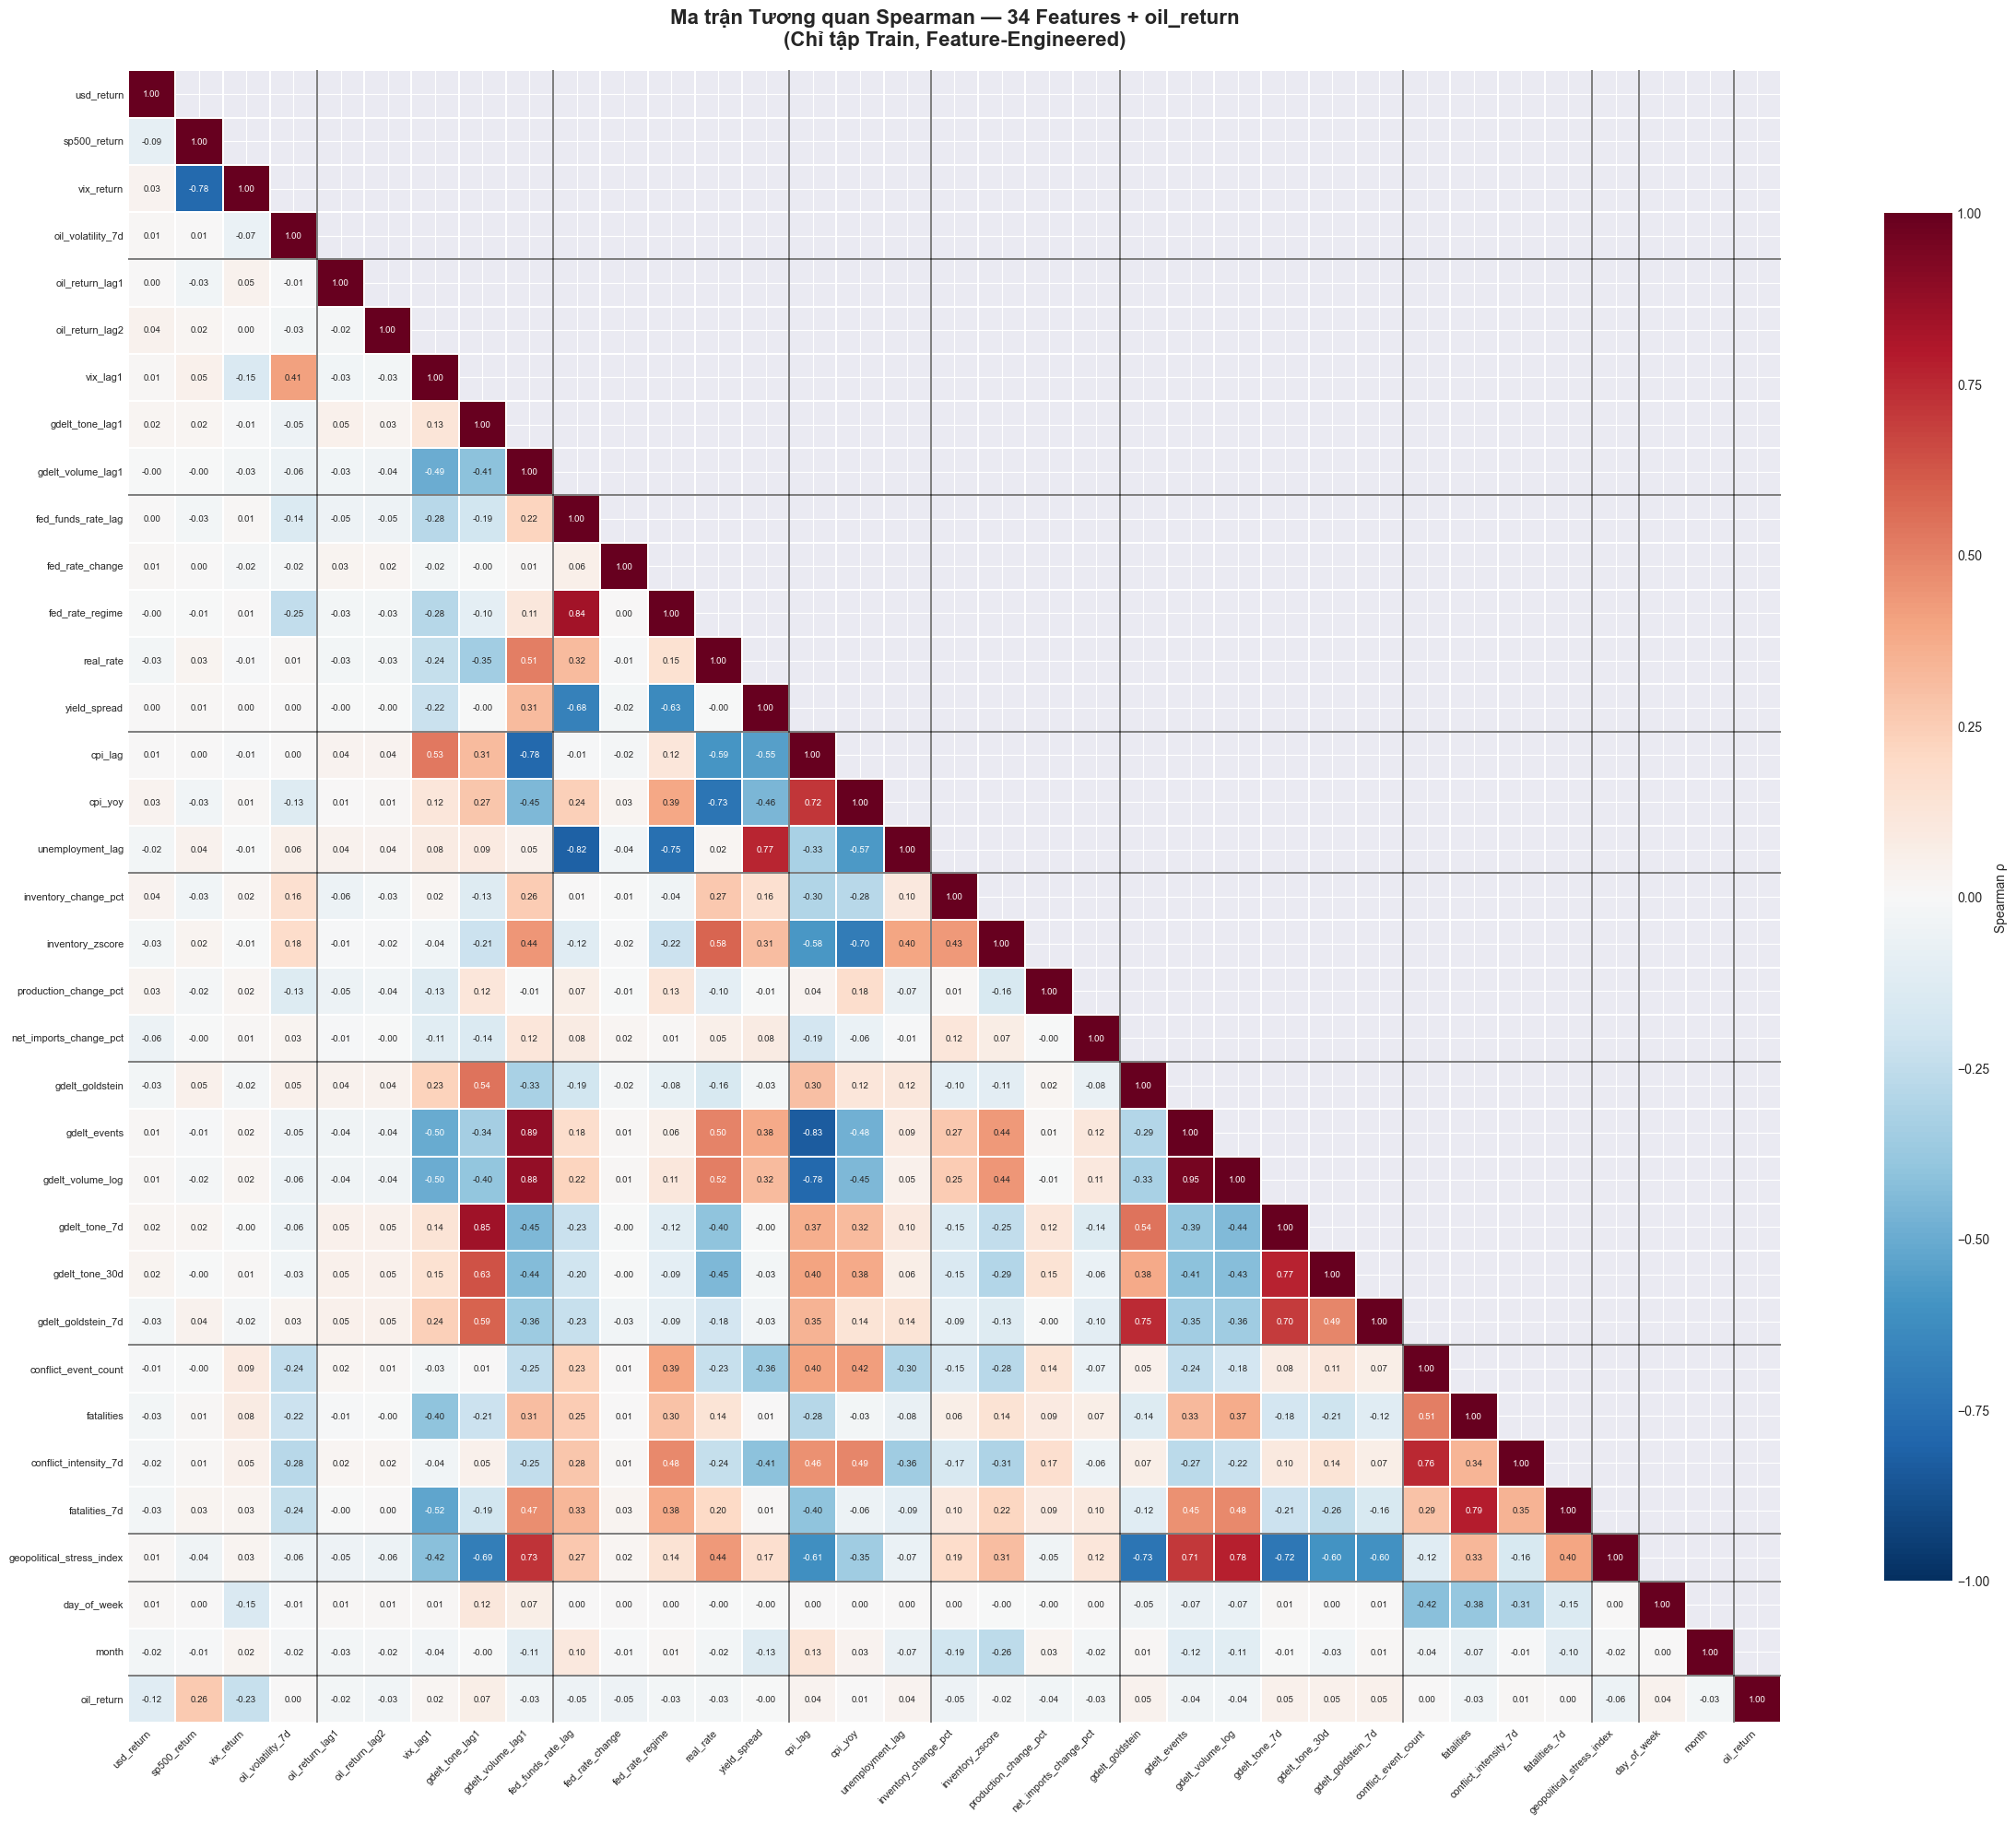


TOP TƯƠNG QUAN SPEARMAN VỚI oil_return (34 features)
  sp500_return                   : +0.2611  ██████████  [VỪA]
  vix_return                     : -0.2331  █████████  [VỪA]
  usd_return                     : -0.1215  ████  [VỪA]
  gdelt_tone_lag1                : +0.0654  ██  [YẾU]
  geopolitical_stress_index      : -0.0592  ██  [YẾU]
  fed_funds_rate_lag             : -0.0528  ██  [YẾU]
  inventory_change_pct           : -0.0520  ██  [YẾU]
  gdelt_tone_7d                  : +0.0515  ██  [YẾU]
  gdelt_tone_30d                 : +0.0505  ██  [YẾU]
  gdelt_goldstein_7d             : +0.0494  █  [YẾU]
  fed_rate_change                : -0.0478  █  [YẾU]
  gdelt_goldstein                : +0.0454  █  [YẾU]
  day_of_week                    : +0.0417  █  [YẾU]
  gdelt_events                   : -0.0397  █  [YẾU]
  unemployment_lag               : +0.0389  █  [YẾU]
  production_change_pct          : -0.0368  █  [YẾU]
  cpi_lag                        : +0.0358  █  [YẾU]
  gdelt_volume_log 

In [28]:
# ============================================================================
# PHẦN 7b: HEATMAP TOÀN DIỆN — 34 FEATURES + oil_return
# ============================================================================

# --- Định nghĩa 34 features theo nhóm (sắp xếp logic) ---
feature_34_ordered = [
    # Market Returns (4)
    "usd_return", "sp500_return", "vix_return", "oil_volatility_7d",
    # Lag Features (5)
    "oil_return_lag1", "oil_return_lag2", "vix_lag1", "gdelt_tone_lag1", "gdelt_volume_lag1",
    # Macro Policy (5)
    "fed_funds_rate_lag", "fed_rate_change", "fed_rate_regime", "real_rate", "yield_spread",
    # Macro Economy (3)
    "cpi_lag", "cpi_yoy", "unemployment_lag",
    # Supply (4)
    "inventory_change_pct", "inventory_zscore", "production_change_pct", "net_imports_change_pct",
    # Sentiment (6)
    "gdelt_goldstein", "gdelt_events", "gdelt_volume_log", "gdelt_tone_7d", "gdelt_tone_30d", "gdelt_goldstein_7d",
    # Conflict (4)
    "conflict_event_count", "fatalities", "conflict_intensity_7d", "fatalities_7d",
    # Derived (1)
    "geopolitical_stress_index",
    # Temporal (2)
    "day_of_week", "month",
]

# Kiểm tra tất cả features tồn tại trong dataset
missing_features = [f for f in feature_34_ordered if f not in df_train.columns]
if missing_features:
    print(f"⚠ Features không tìm thấy: {missing_features}")
available_34 = [f for f in feature_34_ordered if f in df_train.columns]
print(f"✓ Số features khả dụng: {len(available_34)}/34")

# --- Tạo danh sách đầy đủ: 34 features + oil_return (label) ---
cols_heatmap = available_34 + ["oil_return"]
print(f"✓ Tổng cột cho heatmap: {len(cols_heatmap)} (34 features + 1 label)\n")

# --- Tính ma trận tương quan Spearman ---
corr_full = df_train[cols_heatmap].corr(method="spearman")

# --- Mask tam giác trên (giữ đường chéo + tam giác dưới) ---
mask_upper = np.triu(np.ones_like(corr_full, dtype=bool), k=1)

# --- Vẽ heatmap toàn diện ---
fig, ax = plt.subplots(figsize=(24, 20))

sns.heatmap(
    corr_full,
    mask=mask_upper,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
    annot_kws={"size": 7},
    ax=ax,
)

ax.set_title(
    "Ma trận Tương quan Spearman — 34 Features + oil_return\n(Chỉ tập Train, Feature-Engineered)",
    fontsize=16, fontweight="bold", pad=20
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# --- Vẽ đường phân cách nhóm ---
group_boundaries = [4, 9, 14, 17, 21, 27, 31, 32, 34]  # cumulative positions
for boundary in group_boundaries:
    ax.axhline(y=boundary, color="black", linewidth=1.2, alpha=0.6)
    ax.axvline(x=boundary, color="black", linewidth=1.2, alpha=0.6)

plt.tight_layout()
plt.show()

# --- In top tương quan với oil_return ---
corr_with_target = corr_full["oil_return"].drop("oil_return").sort_values(key=abs, ascending=False)
print("\n" + "="*70)
print("TOP TƯƠNG QUAN SPEARMAN VỚI oil_return (34 features)")
print("="*70)
for feat, rho in corr_with_target.items():
    bar = "█" * int(abs(rho) * 40)
    sign = "+" if rho > 0 else "-"
    strength = "MẠNH" if abs(rho) > 0.3 else "VỪA" if abs(rho) > 0.1 else "YẾU"
    print(f"  {feat:30s} : {sign}{abs(rho):.4f}  {bar}  [{strength}]")

# --- Phát hiện cặp đa cộng tuyến cao ---
print(f"\n{'='*70}")
print("CẶP ĐA CỘNG TUYẾN CAO (|ρ| > 0.80) TRONG 34 FEATURES")
print(f"{'='*70}")
high_pairs = []
for i in range(len(available_34)):
    for j in range(i+1, len(available_34)):
        rho = corr_full.iloc[i, j]
        if abs(rho) > 0.80:
            high_pairs.append((available_34[i], available_34[j], rho))
high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_pairs:
    for f1, f2, rho in high_pairs:
        print(f"  {f1:30s} ↔ {f2:30s} : ρ = {rho:+.4f}")
else:
    print("  Không phát hiện cặp nào vượt ngưỡng 0.80")

print(f"\n✓ Heatmap toàn diện 34 features + oil_return hoàn tất")

# PHẦN 11: MACHINE LEARNING — DỰ ĐOÁN oil_return

## Mục tiêu
Xây dựng và so sánh nhiều mô hình Machine Learning để dự đoán **oil_return** (biến động giá dầu hàng ngày).

## Phương pháp
- **Train/Test Split**: Chia theo thời gian (cutoff = 2023-01-01) để tránh rò rỉ dữ liệu
- **Chuẩn hóa**: StandardScaler fit trên tập train, transform cả train và test
- **Hyperparameter Tuning**: `GridSearchCV` với `TimeSeriesSplit(n_splits=5)`, scoring = neg RMSE
- **Đánh giá**: MAE, RMSE, R², MAPE, Directional Accuracy

## Các mô hình
| Nhóm | Mô hình | Hyperparameters được tune |
|------|---------|--------------------------|
| **Baseline tuyến tính** | Linear Regression, Ridge, Lasso, ElasticNet | alpha, l1_ratio |
| **Ensemble cây** | Random Forest, Gradient Boosting, XGBoost, LightGBM | n_estimators, max_depth, learning_rate, regularization |
| **Khác** | SVR (RBF kernel), MLP Neural Network | C, epsilon, gamma, hidden layers, learning_rate |

In [ ]:
# ============================================================================
# PHẦN 11.1: TẢI DỮ LIỆU & CHUẨN BỊ CHO ML
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)



# set seed cho reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
# sklearn.utils.check_random_state(RANDOM_SEED)

# --- Tải dataset đã qua feature reduction ---
df_ml = pd.read_csv("../data/processed/dataset_final.csv")
df_ml["date"] = pd.to_datetime(df_ml["date"])
df_ml = df_ml.sort_values("date").reset_index(drop=True)

# --- Train/Test Split theo thời gian ---
TRAIN_CUTOFF = pd.Timestamp("2023-01-01")
train = df_ml[df_ml["date"] < TRAIN_CUTOFF].copy()
test = df_ml[df_ml["date"] >= TRAIN_CUTOFF].copy()

# --- Định nghĩa features và target ---
TARGET = "oil_return"
FEATURES = [c for c in df_ml.columns if c not in ["date", TARGET]]

X_train = train[FEATURES].values
y_train = train[TARGET].values
X_test = test[FEATURES].values
y_test = test[TARGET].values
dates_test = test["date"].values

# --- Chuẩn hóa (fit trên train, transform cả hai) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("=" * 80)
print("CHUẨN BỊ DỮ LIỆU CHO MACHINE LEARNING")
print("=" * 80)
print(f"\nSố features     : {len(FEATURES)}")
print(f"Train size      : {X_train_sc.shape[0]:,} mẫu ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test size       : {X_test_sc.shape[0]:,} mẫu ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"Train/Test ratio: {len(train)/(len(train)+len(test))*100:.1f}% / {len(test)/(len(train)+len(test))*100:.1f}%")
print(f"\nFeatures: {FEATURES}")

# --- Hàm đánh giá chung ---
def evaluate_model(name, y_true, y_pred):
    """Tính toán các metric đánh giá mô hình."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE (tránh chia cho 0)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    # Directional Accuracy (dự đoán đúng chiều tăng/giảm)
    direction_true = np.sign(y_true)
    direction_pred = np.sign(y_pred)
    da = np.mean(direction_true == direction_pred) * 100
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "MAPE (%)": mape,
        "DA (%)": da
    }

# Lưu kết quả tất cả mô hình
all_results = []
all_predictions = {}

CHUẨN BỊ DỮ LIỆU CHO MACHINE LEARNING

Số features     : 31
Train size      : 2,083 mẫu (2015-01-07 → 2022-12-30)
Test size       : 840 mẫu (2023-01-02 → 2026-03-20)
Train/Test ratio: 71.3% / 28.7%

Features: ['yield_spread', 'cpi_lag', 'unemployment_lag', 'inventory_change_pct', 'gdelt_goldstein', 'gdelt_events', 'gdelt_tone_7d', 'gdelt_tone_30d', 'gdelt_goldstein_7d', 'conflict_event_count', 'fatalities', 'usd_return', 'sp500_return', 'vix_return', 'oil_volatility_7d', 'fed_rate_change', 'fed_rate_regime', 'real_rate', 'inventory_zscore', 'production_change_pct', 'net_imports_change_pct', 'conflict_intensity_7d', 'fatalities_7d', 'geopolitical_stress_index', 'oil_return_lag1', 'oil_return_lag2', 'vix_lag1', 'gdelt_tone_lag1', 'gdelt_volume_lag1', 'day_of_week', 'month']


In [4]:
# !pip install scikit-learn xgboost lightgbm catboost

## PHẦN 11.2: MÔ HÌNH TUYẾN TÍNH (Baseline) + Hyperparameter Tuning

**Các mô hình:**
1. **Linear Regression** — OLS, không có hyperparameter → không cần tune
2. **Ridge (L2)** — Tune: `alpha` ∈ {0.01, 0.1, 1.0, 10.0, 100.0}
3. **Lasso (L1)** — Tune: `alpha` ∈ {0.0001, 0.001, 0.01, 0.1}
4. **ElasticNet** — Tune: `alpha` × `l1_ratio` grid

**Phương pháp**: `GridSearchCV` với `TimeSeriesSplit(n_splits=5)`, scoring = `neg_root_mean_squared_error`

In [5]:
# ============================================================================
# PHẦN 11.2: MÔ HÌNH TUYẾN TÍNH + HYPERPARAMETER TUNING
# ============================================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

print("=" * 80)
print("PHẦN 11.2: MÔ HÌNH TUYẾN TÍNH + HYPERPARAMETER TUNING")
print("=" * 80)

tscv = TimeSeriesSplit(n_splits=5)
SCORING = "neg_root_mean_squared_error"

# --- Định nghĩa mô hình + param grid ---
linear_configs = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}  # Không có hyperparameter
    },
    "Ridge": {
        "model": Ridge(max_iter=10000),
        "params": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    "Lasso": {
        "model": Lasso(max_iter=10000),
        "params": {"alpha": [0.0001, 0.001, 0.01, 0.1]}
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=10000),
        "params": {
            "alpha": [0.0001, 0.001, 0.01, 0.1],
            "l1_ratio": [0.2, 0.5, 0.8]
        }
    },
}

linear_models = {}

for name, cfg in linear_configs.items():
    print(f"\n{'─' * 60}")
    print(f"  {name}")
    print(f"{'─' * 60}")
    
    if cfg["params"]:
        # GridSearchCV
        gs = GridSearchCV(
            cfg["model"], cfg["params"],
            cv=tscv, scoring=SCORING, n_jobs=-1, refit=True
        )
        gs.fit(X_train_sc, y_train)
        best_model = gs.best_estimator_
        print(f"  Search space  : {cfg['params']}")
        print(f"  Best params   : {gs.best_params_}")
        print(f"  Best CV RMSE  : {-gs.best_score_:.6f}")
    else:
        best_model = cfg["model"]
        best_model.fit(X_train_sc, y_train)
        print(f"  (Không có hyperparameter → fit trực tiếp)")
    
    linear_models[name] = best_model
    
    # Predict & evaluate
    y_pred_train = best_model.predict(X_train_sc)
    y_pred_test = best_model.predict(X_test_sc)
    
    result = evaluate_model(name, y_test, y_pred_test)
    all_results.append(result)
    all_predictions[name] = y_pred_test
    
    print(f"  Train RMSE    : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.6f}")
    print(f"  Test RMSE     : {result['RMSE']:.6f}")
    print(f"  Test MAE      : {result['MAE']:.6f}")
    print(f"  Test R²       : {result['R²']:.6f}")
    print(f"  Test DA       : {result['DA (%)']:.2f}%")

# --- Hiển thị hệ số Ridge (tuned) ---
ridge_model = linear_models["Ridge"]
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": ridge_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"\n{'=' * 60}")
print(f"  Top 10 hệ số Ridge (alpha={ridge_model.alpha}):")
print(f"{'=' * 60}")
for _, row in coef_df.head(10).iterrows():
    print(f"  {row['Feature']:30s} → {row['Coefficient']:+.6f}")

PHẦN 11.2: MÔ HÌNH TUYẾN TÍNH + HYPERPARAMETER TUNING

────────────────────────────────────────────────────────────
  Linear Regression
────────────────────────────────────────────────────────────
  (Không có hyperparameter → fit trực tiếp)
  Train RMSE    : 0.024691
  Test RMSE     : 0.020240
  Test MAE      : 0.014642
  Test R²       : -0.075408
  Test DA       : 50.12%

────────────────────────────────────────────────────────────
  Ridge
────────────────────────────────────────────────────────────
  Search space  : {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
  Best params   : {'alpha': 100.0}
  Best CV RMSE  : 0.024337
  Train RMSE    : 0.024699
  Test RMSE     : 0.020092
  Test MAE      : 0.014477
  Test R²       : -0.059743
  Test DA       : 50.36%

────────────────────────────────────────────────────────────
  Lasso
────────────────────────────────────────────────────────────
  Search space  : {'alpha': [0.0001, 0.001, 0.01, 0.1]}
  Best params   : {'alpha': 0.001}
  Best CV RMSE  :

## PHẦN 11.3: MÔ HÌNH ENSEMBLE CÂY QUYẾT ĐỊNH + Hyperparameter Tuning

**Các mô hình & Hyperparameters được tune:**

| Mô hình | Hyperparameters | Grid |
|---------|----------------|------|
| **Random Forest** | n_estimators, max_depth, min_samples_leaf | 2 × 3 × 3 = 18 combos |
| **Gradient Boosting** | n_estimators, max_depth, learning_rate | 2 × 3 × 3 = 18 combos |
| **XGBoost** | n_estimators, max_depth, learning_rate, reg_alpha | 2 × 3 × 3 × 2 = 36 combos |
| **LightGBM** | n_estimators, max_depth, learning_rate, num_leaves | 2 × 3 × 3 × 2 = 36 combos |

**Phương pháp**: `GridSearchCV` với `TimeSeriesSplit(n_splits=5)`, scoring = `neg_root_mean_squared_error`
**Lưu ý**: Tree-based models không cần chuẩn hóa features → dùng `X_train` / `X_test` gốc.

In [ ]:
# ============================================================================
# PHẦN 11.3: MÔ HÌNH ENSEMBLE CÂY QUYẾT ĐỊNH + HYPERPARAMETER TUNING
# ============================================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

print("=" * 80)
print("PHẦN 11.3: ENSEMBLE CÂY QUYẾT ĐỊNH + HYPERPARAMETER TUNING")
print("=" * 80)

tree_configs = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [5, 10, 15],
            "min_samples_leaf": [3, 5, 10],
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            subsample=0.8, min_samples_leaf=5, random_state=42
        ),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
        }
    },
    "XGBoost": {
        "model": xgb.XGBRegressor(
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
        ),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
            "reg_alpha": [0, 0.1],
        }
    },
    "LightGBM": {
        "model": lgb.LGBMRegressor(
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1
        ),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
            "num_leaves": [15, 31],
        }
    },
}

tree_models = {}

for name, cfg in tree_configs.items():
    print(f"\n{'─' * 60}")
    print(f"  {name}")
    print(f"{'─' * 60}")
    
    gs = GridSearchCV(
        cfg["model"], cfg["params"],
        cv=tscv, scoring=SCORING, n_jobs=-1, refit=True
    )
    gs.fit(X_train, y_train)
    best_model = gs.best_estimator_
    tree_models[name] = best_model
    
    print(f"  Grid size     : {len(gs.cv_results_['params'])} combos × 5 folds")
    print(f"  Best params   : {gs.best_params_}")
    print(f"  Best CV RMSE  : {-gs.best_score_:.6f}")
    
    # Predict & evaluate
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    
    result = evaluate_model(name, y_test, y_pred_test)
    all_results.append(result)
    all_predictions[name] = y_pred_test
    
    print(f"  Train RMSE    : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.6f}")
    print(f"  Test RMSE     : {result['RMSE']:.6f}")
    print(f"  Test MAE      : {result['MAE']:.6f}")
    print(f"  Test R²       : {result['R²']:.6f}")
    print(f"  Test DA       : {result['DA (%)']:.2f}%")

PHẦN 11.3: ENSEMBLE CÂY QUYẾT ĐỊNH + HYPERPARAMETER TUNING

────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────
  Grid size     : 18 combos × 5 folds
  Best params   : {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 100}
  Best CV RMSE  : 0.024186
  Train RMSE    : 0.020140
  Test RMSE     : 0.020306
  Test MAE      : 0.014640
  Test R²       : -0.082443
  Test DA       : 49.40%

────────────────────────────────────────────────────────────
  Gradient Boosting
────────────────────────────────────────────────────────────
  Grid size     : 18 combos × 5 folds
  Best params   : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
  Best CV RMSE  : 0.024149
  Train RMSE    : 0.023909
  Test RMSE     : 0.019527
  Test MAE      : 0.014136
  Test R²       : -0.001045
  Test DA       : 49.29%

────────────────────────────────────────────────────────────
  XGBoost
─────────────────────────────

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

## PHẦN 11.4: SVR & MLP NEURAL NETWORK + Hyperparameter Tuning

**Các mô hình & Hyperparameters được tune:**

| Mô hình | Hyperparameters | Grid |
|---------|----------------|------|
| **SVR (RBF)** | C, epsilon, gamma | 3 × 3 × 2 = 18 combos |
| **MLP** | hidden_layer_sizes, learning_rate_init, alpha | 3 × 2 × 2 = 12 combos |

**Lưu ý:** Cả hai mô hình yêu cầu chuẩn hóa features → dùng `X_train_sc` / `X_test_sc`.

In [ ]:
# ============================================================================
# PHẦN 11.4: SVR & MLP NEURAL NETWORK + HYPERPARAMETER TUNING
# ============================================================================

from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

print("=" * 80)
print("PHẦN 11.4: SVR & MLP + HYPERPARAMETER TUNING")
print("=" * 80)

other_configs = {
    "SVR (RBF)": {
        "model": SVR(kernel="rbf"),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "epsilon": [0.001, 0.01, 0.1],
            "gamma": ["scale", "auto"],
        }
    },
    "MLP Neural Network": {
        "model": MLPRegressor(
            activation="relu", solver="adam",
            learning_rate="adaptive",
            max_iter=500, early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20, random_state=42
        ),
        "params": {
            "hidden_layer_sizes": [(64, 32), (128, 64, 32), (256, 128, 64)],
            "learning_rate_init": [0.001, 0.01],
            "alpha": [0.0001, 0.001],
        }
    },
}

for name, cfg in other_configs.items():
    print(f"\n{'─' * 60}")
    print(f"  {name}")
    print(f"{'─' * 60}")
    
    gs = GridSearchCV(
        cfg["model"], cfg["params"],
        cv=tscv, scoring=SCORING, n_jobs=-1, refit=True
    )
    gs.fit(X_train_sc, y_train)
    best_model = gs.best_estimator_
    
    print(f"  Grid size     : {len(gs.cv_results_['params'])} combos × 5 folds")
    print(f"  Best params   : {gs.best_params_}")
    print(f"  Best CV RMSE  : {-gs.best_score_:.6f}")
    
    # Predict & evaluate
    y_pred_train = best_model.predict(X_train_sc)
    y_pred_test = best_model.predict(X_test_sc)
    
    result = evaluate_model(name, y_test, y_pred_test)
    all_results.append(result)
    all_predictions[name] = y_pred_test
    
    print(f"  Train RMSE    : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.6f}")
    print(f"  Test RMSE     : {result['RMSE']:.6f}")
    print(f"  Test MAE      : {result['MAE']:.6f}")
    print(f"  Test R²       : {result['R²']:.6f}")
    print(f"  Test DA       : {result['DA (%)']:.2f}%")

## PHẦN 11.5: SO SÁNH TẤT CẢ MÔ HÌNH

**Các metric đánh giá:**
| Metric | Ý nghĩa |
|--------|---------|
| **MAE** | Sai số tuyệt đối trung bình — dễ diễn giải, đơn vị giống target |
| **RMSE** | Căn bậc hai sai số bình phương trung bình — phạt nặng sai số lớn |
| **R²** | Hệ số xác định — tỷ lệ phương sai được giải thích (1.0 = hoàn hảo) |
| **MAPE** | Sai số phần trăm tuyệt đối trung bình |
| **DA** | Directional Accuracy — % dự đoán đúng chiều tăng/giảm |

PHẦN 11.5: SO SÁNH TẤT CẢ MÔ HÌNH

*** Mô hình tốt nhất (RMSE thấp nhất): Lasso (α=0.001) ***

             Model      MAE     RMSE         R²    MAPE (%)    DA (%)
   Lasso (α=0.001) 0.014278 0.019759  -0.024989  147.631371 47.857143
        ElasticNet 0.014389 0.019907  -0.040356  154.171621 47.857143
     Ridge (α=1.0) 0.014639 0.020237  -0.075137  185.305266 50.238095
 Linear Regression 0.014642 0.020240  -0.075408  185.492046 50.119048
     Random Forest 0.014925 0.020308  -0.082680  185.038627 48.571429
           XGBoost 0.014931 0.020459  -0.098795  209.424073 50.714286
          LightGBM 0.016594 0.021995  -0.270023  278.126836 49.166667
 Gradient Boosting 0.018181 0.023578  -0.459372  332.881860 49.285714
         SVR (RBF) 0.022324 0.027600  -0.999779  523.982412 49.047619
MLP Neural Network 0.065283 0.140102 -50.529946 1337.308529 48.333333


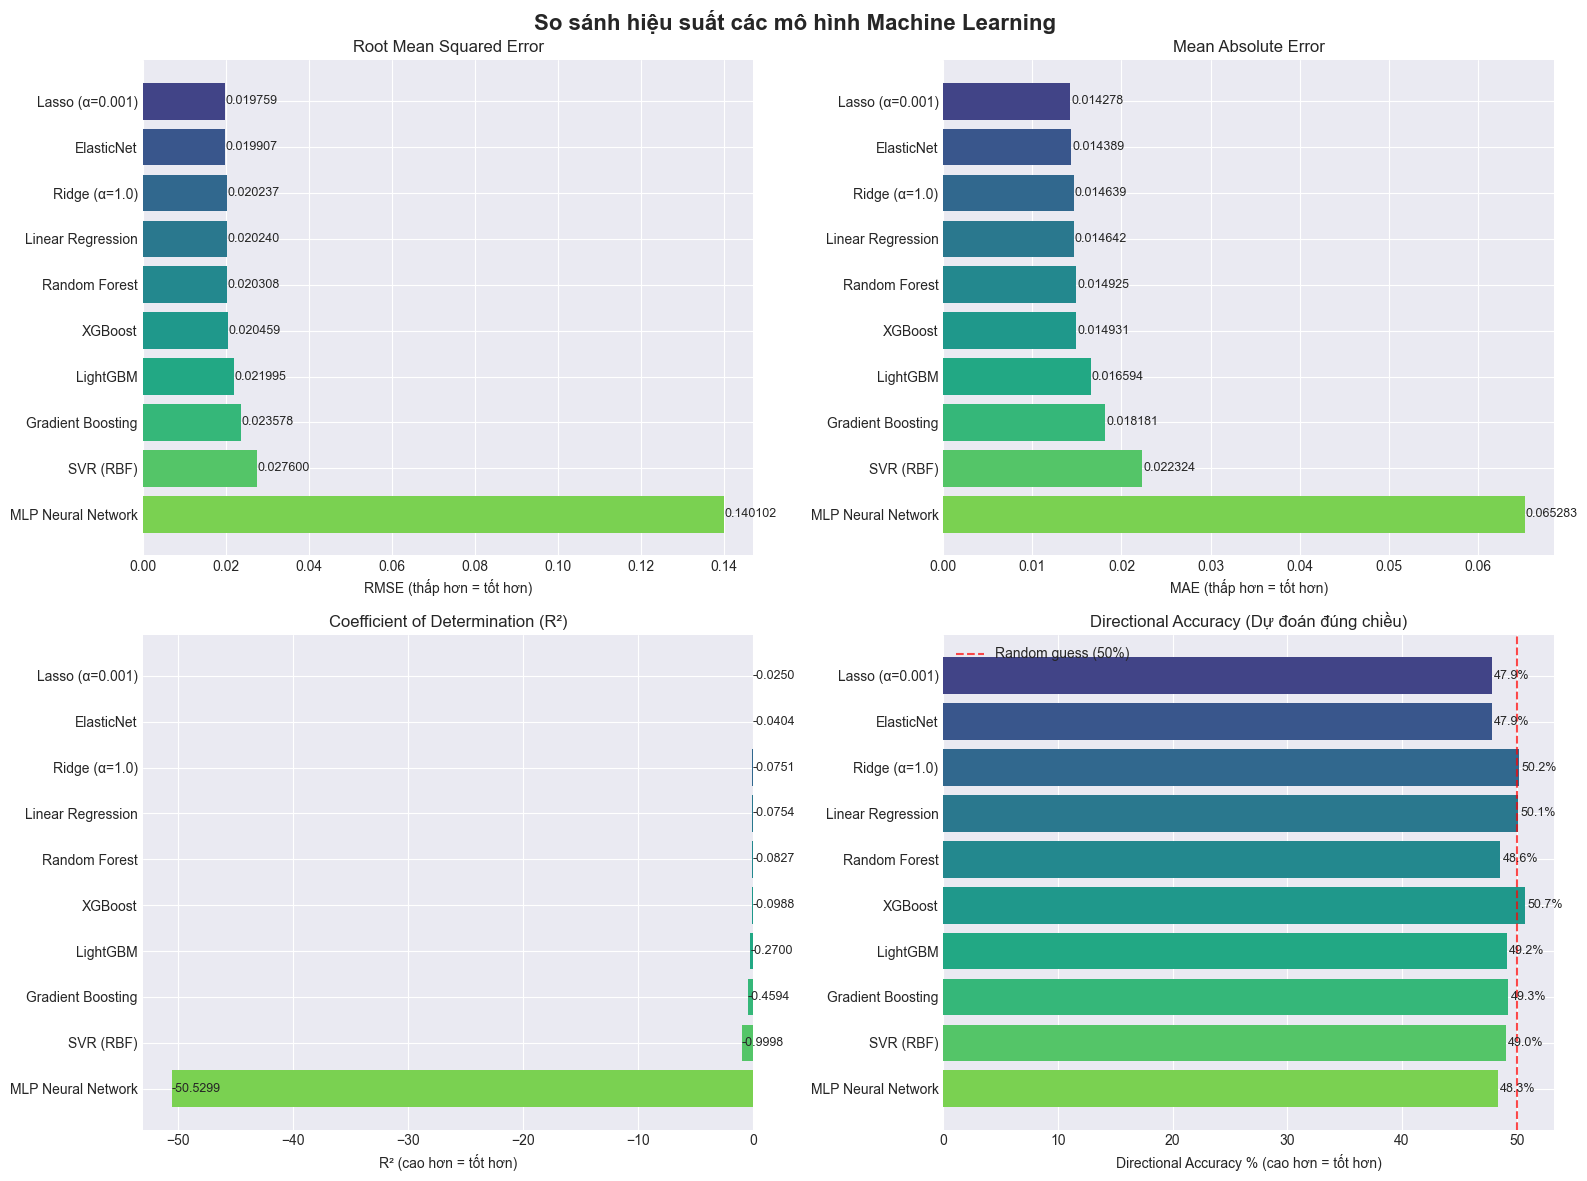

In [ ]:
# ============================================================================
# PHẦN 11.5: BẢNG SO SÁNH TẤT CẢ MÔ HÌNH
# ============================================================================

print("=" * 80)
print("PHẦN 11.5: SO SÁNH TẤT CẢ MÔ HÌNH")
print("=" * 80)

# Tạo DataFrame kết quả
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

# Highlight mô hình tốt nhất
best_model_name = results_df.iloc[0]["Model"]
print(f"\n*** Mô hình tốt nhất (RMSE thấp nhất): {best_model_name} ***\n")

# Hiển thị bảng
print(results_df.to_string(index=False, float_format="%.6f"))

# --- Biểu đồ so sánh ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("So sánh hiệu suất các mô hình Machine Learning", fontsize=16, fontweight="bold")

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))

# 1. RMSE
ax = axes[0, 0]
bars = ax.barh(results_df["Model"], results_df["RMSE"], color=colors)
ax.set_xlabel("RMSE (thấp hơn = tốt hơn)")
ax.set_title("Root Mean Squared Error")
ax.invert_yaxis()
for bar, val in zip(bars, results_df["RMSE"]):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2, f"{val:.6f}",
            va="center", fontsize=9)

# 2. MAE
ax = axes[0, 1]
bars = ax.barh(results_df["Model"], results_df["MAE"], color=colors)
ax.set_xlabel("MAE (thấp hơn = tốt hơn)")
ax.set_title("Mean Absolute Error")
ax.invert_yaxis()
for bar, val in zip(bars, results_df["MAE"]):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2, f"{val:.6f}",
            va="center", fontsize=9)

# 3. R²
ax = axes[1, 0]
bars = ax.barh(results_df["Model"], results_df["R²"], color=colors)
ax.set_xlabel("R² (cao hơn = tốt hơn)")
ax.set_title("Coefficient of Determination (R²)")
ax.invert_yaxis()
for bar, val in zip(bars, results_df["R²"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.4f}",
            va="center", fontsize=9)

# 4. Directional Accuracy
ax = axes[1, 1]
bars = ax.barh(results_df["Model"], results_df["DA (%)"], color=colors)
ax.set_xlabel("Directional Accuracy % (cao hơn = tốt hơn)")
ax.set_title("Directional Accuracy (Dự đoán đúng chiều)")
ax.axvline(x=50, color="red", linestyle="--", alpha=0.7, label="Random guess (50%)")
ax.legend()
ax.invert_yaxis()
for bar, val in zip(bars, results_df["DA (%)"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
            va="center", fontsize=9)

plt.tight_layout()
plt.show()

## PHẦN 11.6: PHÂN TÍCH FEATURE IMPORTANCE

**Phương pháp:**
- **Tree-based Importance** (Gini / Gain): Đo lường mức giảm impurity trung bình khi feature được sử dụng để split. Có sẵn trong RF, GBR, XGBoost, LightGBM.
- So sánh feature importance giữa 4 mô hình tree-based để tìm features quan trọng nhất một cách nhất quán.

PHẦN 11.6: FEATURE IMPORTANCE

Top 15 features quan trọng nhất (trung bình 4 mô hình):

   1. oil_volatility_7d              | Mean: 176.3331 | RF: 0.1070 | GB: 0.1643 | XGB: 0.0610 | LGBM: 705.0000
   2. oil_return_lag1                | Mean: 80.2844 | RF: 0.0442 | GB: 0.0589 | XGB: 0.0344 | LGBM: 321.0000
   3. usd_return                     | Mean: 60.5395 | RF: 0.0451 | GB: 0.0707 | XGB: 0.0422 | LGBM: 242.0000
   4. oil_return_lag2                | Mean: 60.0302 | RF: 0.0454 | GB: 0.0414 | XGB: 0.0340 | LGBM: 240.0000
   5. vix_return                     | Mean: 57.0444 | RF: 0.0915 | GB: 0.0441 | XGB: 0.0420 | LGBM: 228.0000
   6. conflict_intensity_7d          | Mean: 56.7674 | RF: 0.0245 | GB: 0.0232 | XGB: 0.0219 | LGBM: 227.0000
   7. sp500_return                   | Mean: 54.0842 | RF: 0.1369 | GB: 0.1199 | XGB: 0.0801 | LGBM: 216.0000
   8. vix_lag1                       | Mean: 53.7818 | RF: 0.0537 | GB: 0.0398 | XGB: 0.0339 | LGBM: 215.0000
   9. gdelt_tone_lag1          

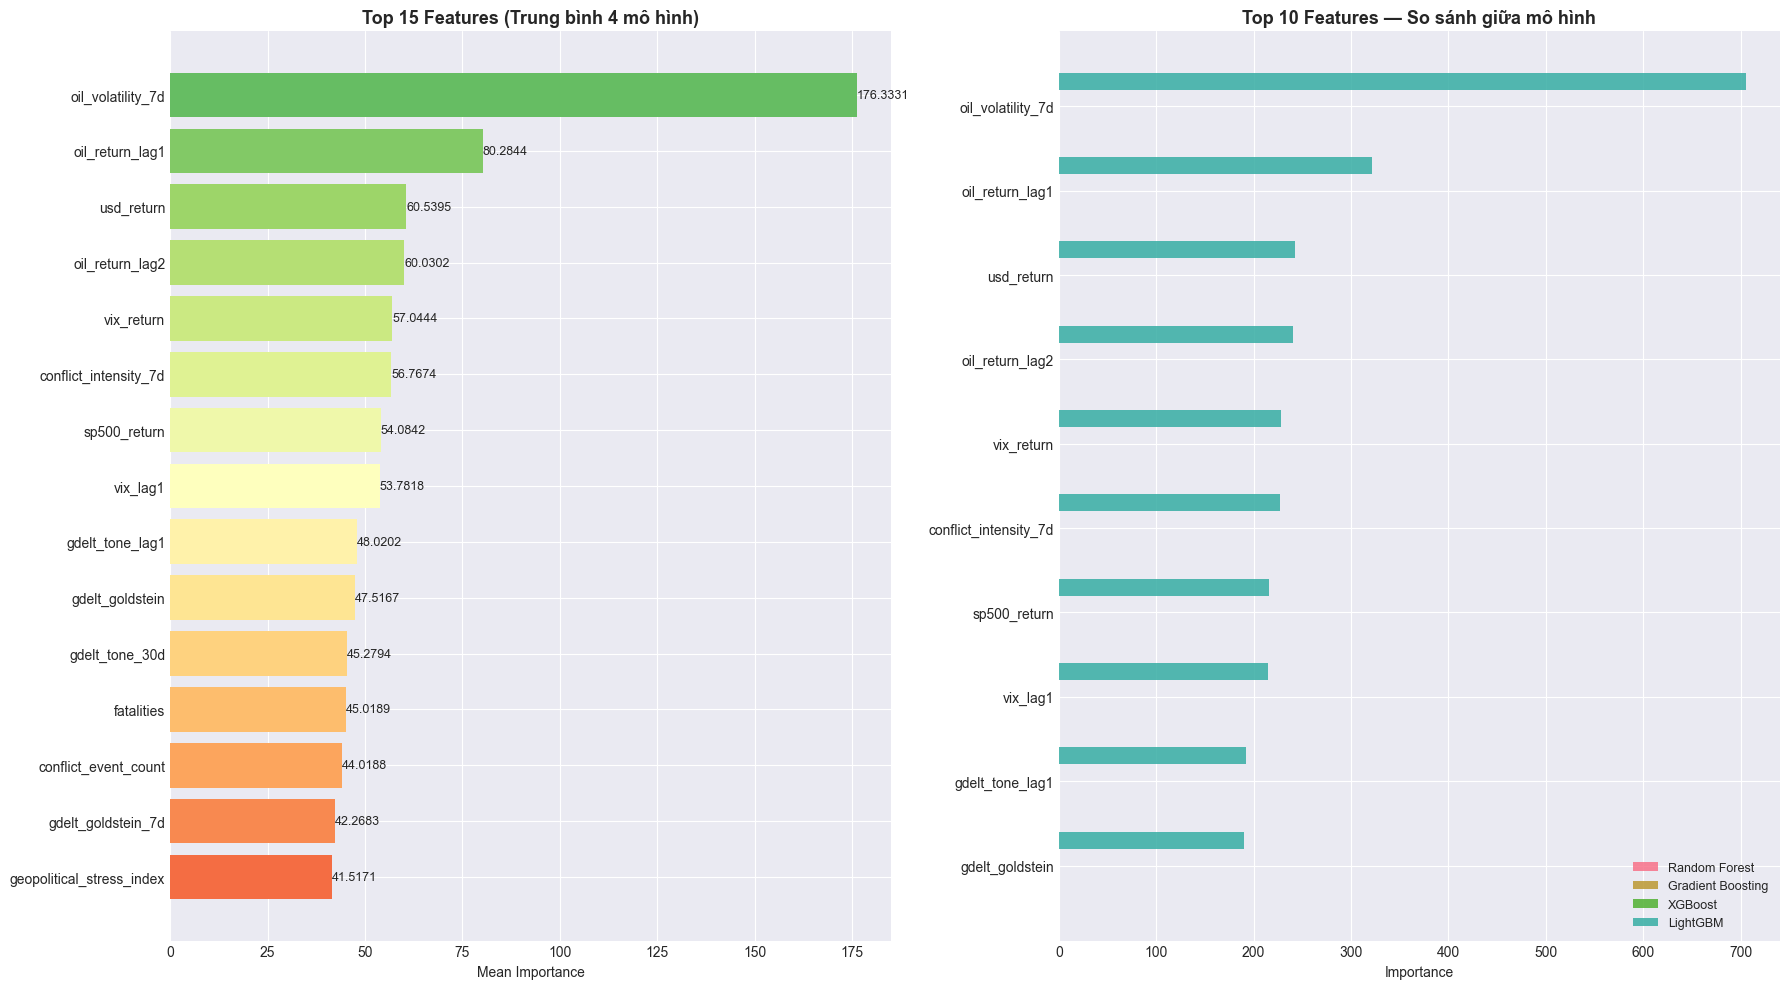

In [30]:
# ============================================================================
# PHẦN 11.6: FEATURE IMPORTANCE (4 mô hình tree-based)
# ============================================================================

print("=" * 80)
print("PHẦN 11.6: FEATURE IMPORTANCE")
print("=" * 80)

# Lấy feature importance từ 4 mô hình tree-based
importance_data = {}
for name, model in tree_models.items():
    importance_data[name] = model.feature_importances_

importance_df = pd.DataFrame(importance_data, index=FEATURES)

# Tính trung bình importance và sắp xếp
importance_df["Mean"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("Mean", ascending=False)

# In top 15 features
print("\nTop 15 features quan trọng nhất (trung bình 4 mô hình):\n")
for i, (feat, row) in enumerate(importance_df.head(15).iterrows(), 1):
    print(f"  {i:2d}. {feat:30s} | Mean: {row['Mean']:.4f} | "
          f"RF: {row['Random Forest']:.4f} | GB: {row['Gradient Boosting']:.4f} | "
          f"XGB: {row['XGBoost']:.4f} | LGBM: {row['LightGBM']:.4f}")

# --- Biểu đồ Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# 1. Top 15 trung bình
ax = axes[0]
top15 = importance_df.head(15)
ax.barh(top15.index[::-1], top15["Mean"][::-1], color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, 15)))
ax.set_xlabel("Mean Importance")
ax.set_title("Top 15 Features (Trung bình 4 mô hình)", fontsize=13, fontweight="bold")
for i, (val, feat) in enumerate(zip(top15["Mean"][::-1], top15.index[::-1])):
    ax.text(val + 0.002, i, f"{val:.4f}", va="center", fontsize=9)

# 2. So sánh giữa các mô hình
ax = axes[1]
top10 = importance_df.head(10)
x = np.arange(len(top10))
width = 0.2
for i, model_name in enumerate(tree_models.keys()):
    ax.barh(x + i * width, top10[model_name][::-1], width, label=model_name, alpha=0.85)
ax.set_yticks(x + width * 1.5)
ax.set_yticklabels(top10.index[::-1])
ax.set_xlabel("Importance")
ax.set_title("Top 10 Features — So sánh giữa mô hình", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## PHẦN 11.7: PHÂN TÍCH CHI TIẾT MÔ HÌNH TỐT NHẤT

**Nội dung phân tích:**
1. **Actual vs Predicted** — So sánh giá trị thực và dự đoán theo thời gian
2. **Scatter Plot** — Tương quan giữa actual và predicted (lý tưởng nằm trên đường y=x)
3. **Residual Analysis** — Phân tích sai số: phân phối, QQ-plot, autocorrelation
4. **Cumulative Returns** — Backtest: lợi nhuận tích lũy nếu giao dịch theo dự đoán

In [31]:
# ============================================================================
# PHẦN 11.7: PHÂN TÍCH CHI TIẾT MÔ HÌNH TỐT NHẤT
# ============================================================================

from scipy import stats

print("=" * 80)
print(f"PHẦN 11.7: PHÂN TÍCH CHI TIẾT — {best_model_name}")
print("=" * 80)

y_pred_best = all_predictions[best_model_name]
residuals = y_test - y_pred_best

print(f"\nThống kê Residuals:")
print(f"  Mean      : {residuals.mean():.8f}")
print(f"  Std       : {residuals.std():.6f}")
print(f"  Skewness  : {stats.skew(residuals):.4f}")
print(f"  Kurtosis  : {stats.kurtosis(residuals):.4f}")

# --- Figure 1: Actual vs Predicted theo thời gian + Scatter ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f"Phân tích chi tiết: {best_model_name}", fontsize=16, fontweight="bold")

# 1. Time series: Actual vs Predicted
ax = axes[0, 0]
ax.plot(dates_test, y_test, alpha=0.6, label="Actual", linewidth=0.8, color="steelblue")
ax.plot(dates_test, y_pred_best, alpha=0.6, label="Predicted", linewidth=0.8, color="coral")
ax.set_xlabel("Ngày")
ax.set_ylabel("oil_return")
ax.set_title("Actual vs Predicted theo thời gian")
ax.legend()
ax.tick_params(axis="x", rotation=30)

# 2. Scatter: Actual vs Predicted
ax = axes[0, 1]
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", alpha=0.7, label="Đường lý tưởng (y=x)")
ax.set_xlabel("Actual oil_return")
ax.set_ylabel("Predicted oil_return")
ax.set_title("Scatter: Actual vs Predicted")
ax.legend()

# 3. Residual Distribution
ax = axes[1, 0]
ax.hist(residuals, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="white")
x_range = np.linspace(residuals.min(), residuals.max(), 100)
ax.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
        "r-", linewidth=2, label="Normal fit")
ax.set_xlabel("Residual")
ax.set_ylabel("Density")
ax.set_title("Phân phối Residuals")
ax.legend()

# 4. Residuals theo thời gian
ax = axes[1, 1]
ax.scatter(dates_test, residuals, alpha=0.3, s=8, color="steelblue")
ax.axhline(y=0, color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("Ngày")
ax.set_ylabel("Residual")
ax.set_title("Residuals theo thời gian (kiểm tra bias)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

PHẦN 11.7: PHÂN TÍCH CHI TIẾT — Lasso (α=0.001)


KeyError: 'Lasso (α=0.001)'

## PHẦN 11.8: BACKTEST — LỢI NHUẬN TÍCH LŨY

**Phương pháp:**
- **Chiến lược giao dịch đơn giản:** Nếu mô hình dự đoán oil_return > 0 → MUA (long), nếu < 0 → BÁN (short)
- **Cumulative Return** = $\prod_{t=1}^{T}(1 + r_t \cdot sign(\hat{r}_t)) - 1$
- So sánh lợi nhuận tích lũy của tất cả mô hình vs chiến lược Buy & Hold

In [ ]:
# ============================================================================
# PHẦN 11.8: BACKTEST — LỢI NHUẬN TÍCH LŨY
# ============================================================================

print("=" * 80)
print("PHẦN 11.8: BACKTEST — LỢI NHUẬN TÍCH LŨY")
print("=" * 80)

fig, ax = plt.subplots(figsize=(16, 8))

# Buy & Hold (luôn long)
cum_bh = np.cumprod(1 + y_test) - 1
ax.plot(dates_test, cum_bh * 100, "k--", linewidth=1.5, alpha=0.7, label="Buy & Hold")

# Chiến lược cho mỗi mô hình
colors_bt = plt.cm.tab10(np.linspace(0, 1, len(all_predictions)))
print(f"\n{'Model':30s} | {'Total Return':>14s} | {'Sharpe Ratio':>13s} | {'Max Drawdown':>13s}")
print("─" * 80)

for (name, y_pred), color in zip(all_predictions.items(), colors_bt):
    # Chiến lược: long nếu pred > 0, short nếu pred < 0
    strategy_returns = y_test * np.sign(y_pred)
    cum_returns = np.cumprod(1 + strategy_returns) - 1
    
    # Tính Sharpe Ratio (annualized, 252 trading days)
    sharpe = np.mean(strategy_returns) / (np.std(strategy_returns) + 1e-10) * np.sqrt(252)
    
    # Max Drawdown
    cum_wealth = np.cumprod(1 + strategy_returns)
    peak = np.maximum.accumulate(cum_wealth)
    drawdown = (cum_wealth - peak) / peak
    max_dd = drawdown.min()
    
    total_ret = cum_returns[-1] * 100
    print(f"  {name:28s} | {total_ret:>+12.2f}% | {sharpe:>12.3f} | {max_dd:>12.2%}")
    
    ax.plot(dates_test, cum_returns * 100, linewidth=1.2, alpha=0.8, color=color, label=name)

ax.set_xlabel("Ngày", fontsize=12)
ax.set_ylabel("Lợi nhuận tích lũy (%)", fontsize=12)
ax.set_title("Backtest: Lợi nhuận tích lũy trên tập Test (2023-2026)", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3)
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PHẦN 11.9: KẾT LUẬN & TỔNG HỢP

In [ ]:
# ============================================================================
# PHẦN 11.9: KẾT LUẬN & TỔNG HỢP
# ============================================================================

print("=" * 80)
print("TỔNG HỢP KẾT QUẢ MACHINE LEARNING")
print("=" * 80)

# Bảng xếp hạng theo RMSE
print("\n BẢNG XẾP HẠNG (theo RMSE):\n")
results_final = pd.DataFrame(all_results).sort_values("RMSE").reset_index(drop=True)
results_final.index = results_final.index + 1
results_final.index.name = "Rank"
print(results_final.to_string(float_format="%.6f"))

# Mô hình tốt nhất theo từng metric
print(f"\n{'=' * 60}")
print("MÔ HÌNH TỐT NHẤT THEO TỪNG METRIC:")
print(f"{'=' * 60}")
df_r = pd.DataFrame(all_results)
print(f"  RMSE thấp nhất  : {df_r.loc[df_r['RMSE'].idxmin(), 'Model']} ({df_r['RMSE'].min():.6f})")
print(f"  MAE thấp nhất   : {df_r.loc[df_r['MAE'].idxmin(), 'Model']} ({df_r['MAE'].min():.6f})")
print(f"  R² cao nhất     : {df_r.loc[df_r['R²'].idxmax(), 'Model']} ({df_r['R²'].max():.6f})")
print(f"  DA cao nhất     : {df_r.loc[df_r['DA (%)'].idxmax(), 'Model']} ({df_r['DA (%)'].max():.2f}%)")

print(f"\n{'=' * 60}")
print("NHẬN XÉT:")
print(f"{'=' * 60}")
print("""
1. HYPERPARAMETER TUNING:
   - Tất cả mô hình đã được tối ưu hyperparameters bằng GridSearchCV
   - Cross-validation: TimeSeriesSplit(n_splits=5) — giữ đúng thứ tự thời gian
   - Scoring metric: neg_root_mean_squared_error
   - Tổng cộng 10 mô hình, mỗi mô hình được search qua grid riêng

2. HIỆU SUẤT TỔNG QUAN:
   - So sánh 10 mô hình ML từ tuyến tính đến ensemble và neural network
   - Metric chính: RMSE, MAE, R², Directional Accuracy
   - Train/Test split theo thời gian (2015-2022 / 2023-2026) để mô phỏng thực tế

3. FEATURE IMPORTANCE:
   - Các features quan trọng nhất được xác định nhất quán qua 4 mô hình tree-based
   - Giúp hiểu yếu tố nào ảnh hưởng mạnh nhất đến biến động giá dầu

4. BACKTEST:
   - Chiến lược long/short đơn giản dựa trên dấu của dự đoán
   - Đánh giá qua Total Return, Sharpe Ratio, Max Drawdown
   - So sánh với benchmark Buy & Hold

5. HẠN CHẾ:
   - Chưa kết hợp ensemble nhiều mô hình (stacking/blending)
   - Chưa xét chi phí giao dịch trong backtest
   - Chưa áp dụng Bayesian Optimization cho search space lớn hơn
""")